# Traffic Sign Detection trên Kaggle T4  
## EDA định hướng huấn luyện YOLO và chuẩn bị dữ liệu cho DETR

**Dataset:** `pkdarabi/cardetection`  
**Nền tảng:** Kaggle Notebook — GPU Tesla T4 — giới hạn phiên 12 giờ

### Thành viên thực hiện

| MSHV | Họ và tên |
|---|---|
| **KHMT836016** | **Huỳnh Phát Lợi** |
| **KHMT836034** | **Đoàn Huỳnh Thanh Tú** |
| **KHMT836036** | **Võ Phú Vinh** |

### Mục tiêu

1. Khám phá và kiểm định chất lượng bộ dữ liệu Traffic Signs Detection.
2. Dùng kết quả EDA để tự động chọn độ phân giải, batch size và augmentation.
3. Huấn luyện YOLO theo chiến lược nhiều giai đoạn trong ngân sách thời gian.
4. Đánh giá Precision, Recall, mAP@0.5, mAP@0.5:0.95, tốc độ và AP theo lớp.
5. Luôn duy trì một file `/kaggle/working/best.pt`, kể cả khi giai đoạn nâng cao bị dừng vì thời gian hoặc OOM.
6. Xuất toàn bộ bảng, hình, báo cáo, prediction và checkpoint vào Kaggle Output.

## 0. Hướng dẫn chạy trên Kaggle

1. Tạo Kaggle Notebook mới.
2. Chọn **Add Input → Datasets → `pkdarabi/cardetection`**.
3. Trong **Settings**, chọn **Accelerator → GPU T4 x2 hoặc GPU T4**. Notebook mặc định chỉ dùng GPU `0` để ổn định.
4. Bật **Internet** để cài `ultralytics` và tải pretrained weights lần đầu.
5. Chọn **Run All**.

### Cơ chế bảo vệ thời gian và checkpoint

- Ngân sách notebook nội bộ được đặt thấp hơn 12 giờ để dành thời gian đánh giá và đóng gói.
- Stage 1 chạy ở 640 px và tạo checkpoint càng sớm càng tốt.
- Stage 2 chỉ chạy khi còn đủ thời gian.
- Sau mỗi lần Ultralytics lưu model, checkpoint tốt hơn được copy nguyên tử tới:
  - `/kaggle/working/best.pt`
  - `/kaggle/working/traffic_sign_yolo_pipeline/best.pt`
- Nếu OOM, notebook tự giảm batch/độ phân giải và cuối cùng chuyển từ YOLOv8s sang YOLOv8n.
- Nếu chưa kịp fine-tune epoch nào, `best.pt` vẫn tồn tại dưới dạng pretrained fallback; file provenance sẽ ghi rõ trạng thái này.

## 1. Cài đặt thư viện

In [1]:
# Cài tối thiểu, chỉ cài khi môi trường chưa có.
import importlib.util
import subprocess
import sys

REQUIRED = {
    "ultralytics": "ultralytics",
    "yaml": "pyyaml",
    "cv2": "opencv-python-headless",
    "sklearn": "scikit-learn",
    "tabulate": "tabulate",
}

missing = [pip_name for module_name, pip_name in REQUIRED.items()
           if importlib.util.find_spec(module_name) is None]

if missing:
    print("Installing:", missing)
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", *missing
    ])
else:
    print("All required packages are already available.")

Installing: ['ultralytics']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 205.0 MB/s eta 0:00:00


## 2. Cấu hình, reproducibility và thư mục output

In [2]:
# ==========================================================
# 2.1 Imports, reproducibility và cấu hình
# ==========================================================
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
from datetime import datetime, timezone
import hashlib
import json
import math
import os
import random
import shutil
import sys
import warnings
import time
import gc
import traceback

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, ImageFile
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')

try:
    import yaml
except Exception as exc:
    raise RuntimeError('Notebook cần PyYAML; Kaggle thường đã cài sẵn. Lỗi: ' + repr(exc))

try:
    import cv2
except Exception as exc:
    raise RuntimeError('Notebook cần OpenCV; Kaggle thường đã cài sẵn. Lỗi: ' + repr(exc))

try:
    from scipy.spatial.distance import jensenshannon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    from sklearn.cluster import KMeans
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

STUDENT_INFO = [
    {'student_id': 'KHMT836016', 'student_name': 'Huỳnh Phát Lợi'},
    {'student_id': 'KHMT836034', 'student_name': 'Đoàn Huỳnh Thanh Tú'},
    {'student_id': 'KHMT836036', 'student_name': 'Võ Phú Vinh'},
]

CONFIG =  {
    # None = quét toàn bộ; số nguyên = test nhanh từng split.
    'MAX_IMAGES_PER_SPLIT': None,
    'COMPUTE_VISUAL_FEATURES': True,
    'VISUAL_FEATURE_MAX_SIDE': 256,
    'COMPUTE_HASHES': True,
    'COMPUTE_LOCAL_CONTRAST': True,
    'MAX_OBJECTS_FOR_PAIRWISE_IOU': 100,
    'N_RANDOM_VISUALIZATIONS': 24,
    'N_EXTREME_VISUALIZATIONS': 12,
    'CONTACT_SHEET_COLUMNS': 4,
    'JPEG_QUALITY': 92,
}

KNOWN_CLASS_NAMES = [
    'Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100',
    'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20',
    'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50',
    'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80',
    'Speed Limit 90', 'Stop'
]

IS_KAGGLE = Path('/kaggle').exists()
OUT_DIR = Path('/kaggle/working/traffic_sign_yolo_pipeline') if IS_KAGGLE else Path('./traffic_sign_yolo_pipeline')
TABLE_DIR = OUT_DIR / 'tables'
FIG_DIR = OUT_DIR / 'figures'
SAMPLE_DIR = OUT_DIR / 'samples'
COCO_DIR = OUT_DIR / 'coco_annotations'
MODEL_DIR = OUT_DIR / 'model_ready'
REPORT_DIR = OUT_DIR / 'reports'
TRAIN_DIR = OUT_DIR / 'training_runs'
EVAL_DIR = OUT_DIR / 'evaluation'
PRED_DIR = OUT_DIR / 'predictions'
CHECKPOINT_DIR = OUT_DIR / 'checkpoints'
FINAL_DIR = OUT_DIR / 'final_output'

for directory in [OUT_DIR, TABLE_DIR, FIG_DIR, SAMPLE_DIR, COCO_DIR, MODEL_DIR, REPORT_DIR, TRAIN_DIR, EVAL_DIR, PRED_DIR, CHECKPOINT_DIR, FINAL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

NOTEBOOK_START_TIME = time.time()
TOTAL_BUDGET_HOURS = 11.0
TRAINING_STOP_HOURS = 9.5
MIN_REMAINING_FOR_STAGE2_HOURS = 2.0

def elapsed_hours():
    return (time.time() - NOTEBOOK_START_TIME) / 3600.0

def remaining_hours():
    return max(0.0, TOTAL_BUDGET_HOURS - elapsed_hours())

print('Student information:', json.dumps(STUDENT_INFO, ensure_ascii=False))
print('Python:', sys.version.split()[0])
print('Kaggle environment:', IS_KAGGLE)
print('Output directory:', OUT_DIR.resolve())
print('SciPy available:', SCIPY_AVAILABLE)
print('scikit-learn available:', SKLEARN_AVAILABLE)
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))

Student information: [{"student_id": "KHMT836016", "student_name": "Huỳnh Phát Lợi"}, {"student_id": "KHMT836034", "student_name": "Đoàn Huỳnh Thanh Tú"}, {"student_id": "KHMT836036", "student_name": "Võ Phú Vinh"}]
Python: 3.12.13
Kaggle environment: True
Output directory: /kaggle/working/traffic_sign_yolo_pipeline
SciPy available: True
scikit-learn available: True
{
  "MAX_IMAGES_PER_SPLIT": null,
  "COMPUTE_VISUAL_FEATURES": true,
  "VISUAL_FEATURE_MAX_SIDE": 256,
  "COMPUTE_HASHES": true,
  "COMPUTE_LOCAL_CONTRAST": true,
  "MAX_OBJECTS_FOR_PAIRWISE_IOU": 100,
  "N_RANDOM_VISUALIZATIONS": 24,
  "N_EXTREME_VISUALIZATIONS": 12,
  "CONTACT_SHEET_COLUMNS": 4,
  "JPEG_QUALITY": 92
}


## 3. Tự động dò dataset và đọc metadata

Dataset Kaggle có thể được mount dưới các đường dẫn khác nhau tùy phiên bản. Cell dưới đây không giả định cứng một đường dẫn duy nhất mà tìm:

- `data.yaml`
- `train/images`, `valid/images`, `test/images`
- thư mục `labels` tương ứng

Điều này giúp notebook ổn định khi Kaggle thay đổi tên thư mục cấp ngoài.

In [3]:
# ==========================================================
# 3.1 Dataset discovery
# ==========================================================
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
SPLIT_ALIASES = {
    'train': ['train', 'training'],
    'valid': ['valid', 'val', 'validation'],
    'test': ['test', 'testing'],
}


def candidate_search_roots():
    roots = []
    manual = os.getenv('TRAFFIC_SIGNS_DATA_ROOT', '').strip()
    if manual:
        roots.append(Path(manual))
    if IS_KAGGLE:
        roots.extend([
            Path('/kaggle/input/cardetection'),
            Path('/kaggle/input'),
        ])
    roots.extend([
        Path.cwd(),
        Path.cwd() / 'cardetection',
        Path.cwd() / 'car',
        Path.cwd() / 'data',
        Path.cwd() / 'data' / 'car',
    ])
    unique = []
    seen = set()
    for root in roots:
        try:
            key = str(root.resolve())
        except Exception:
            key = str(root)
        if root.exists() and key not in seen:
            unique.append(root)
            seen.add(key)
    return unique


def find_yaml_files(roots):
    found = []
    for root in roots:
        try:
            found.extend(root.rglob('data.yaml'))
            found.extend(root.rglob('data.yml'))
        except Exception:
            continue
    return sorted(set(found), key=lambda p: (len(str(p)), str(p)))


def find_split_image_dirs(roots):
    result = {}
    for canonical, aliases in SPLIT_ALIASES.items():
        candidates = []
        for root in roots:
            for alias in aliases:
                try:
                    candidates.extend(root.rglob(f'{alias}/images'))
                except Exception:
                    continue
        candidates = [p for p in candidates if p.is_dir()]
        candidates = sorted(set(candidates), key=lambda p: (len(str(p)), str(p)))
        if candidates:
            # Ưu tiên thư mục có nhiều ảnh nhất; nếu bằng nhau ưu tiên path ngắn.
            scored = []
            for p in candidates:
                try:
                    count = sum(1 for f in p.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS)
                except Exception:
                    count = 0
                scored.append((count, -len(str(p)), p))
            result[canonical] = max(scored, key=lambda x: (x[0], x[1]))[2]
    return result


SEARCH_ROOTS = candidate_search_roots()
YAML_FILES = find_yaml_files(SEARCH_ROOTS)
SPLIT_IMAGE_DIRS = find_split_image_dirs(SEARCH_ROOTS)

print('Search roots:')
for p in SEARCH_ROOTS:
    print(' -', p)

print('\nYAML candidates:')
for p in YAML_FILES[:20]:
    print(' -', p)

print('\nDetected split image directories:')
for split, p in SPLIT_IMAGE_DIRS.items():
    print(f' - {split}: {p}')

if not SPLIT_IMAGE_DIRS:
    raise FileNotFoundError(
        'Không tìm thấy train/valid/test images. Trên Kaggle hãy Add Input: pkdarabi/cardetection. '
        'Ngoài Kaggle, có thể đặt biến môi trường TRAFFIC_SIGNS_DATA_ROOT.'
    )

Search roots:
 - /kaggle/input
 - /kaggle/working

YAML candidates:
 - /kaggle/input/datasets/pkdarabi/cardetection/car/data.yaml

Detected split image directories:
 - train: /kaggle/input/datasets/pkdarabi/cardetection/car/train/images
 - valid: /kaggle/input/datasets/pkdarabi/cardetection/car/valid/images
 - test: /kaggle/input/datasets/pkdarabi/cardetection/car/test/images


In [4]:
# ==========================================================
# 3.2 Read data.yaml and class names
# ==========================================================
def normalize_names(names):
    if isinstance(names, list):
        return [str(x) for x in names]
    if isinstance(names, dict):
        try:
            return [str(names[k]) for k in sorted(names, key=lambda x: int(x))]
        except Exception:
            return [str(v) for _, v in sorted(names.items(), key=lambda kv: str(kv[0]))]
    return None


yaml_data = {}
yaml_path = YAML_FILES[0] if YAML_FILES else None
if yaml_path:
    with open(yaml_path, 'r', encoding='utf-8', errors='replace') as f:
        yaml_data = yaml.safe_load(f) or {}

CLASS_NAMES = normalize_names(yaml_data.get('names')) or KNOWN_CLASS_NAMES
NC = int(yaml_data.get('nc', len(CLASS_NAMES)))
if NC != len(CLASS_NAMES):
    print(f'WARNING: nc={NC} nhưng names có {len(CLASS_NAMES)} phần tử. Dùng len(names).')
    NC = len(CLASS_NAMES)

class_df = pd.DataFrame({'class_id': range(NC), 'class_name': CLASS_NAMES})
class_df.to_csv(TABLE_DIR / 'class_mapping.csv', index=False)

print('Selected YAML:', yaml_path)
print('Number of classes:', NC)
display(class_df)

if CLASS_NAMES != KNOWN_CLASS_NAMES:
    print('NOTE: Class names đọc từ data.yaml khác danh sách tham khảo; notebook ưu tiên metadata thực tế.')

Selected YAML: /kaggle/input/datasets/pkdarabi/cardetection/car/data.yaml
Number of classes: 15


,class_id,class_name
0,0,Green Light
1,1,Red Light
2,2,Speed Limit 10
3,3,Speed Limit 100
4,4,Speed Limit 110
5,5,Speed Limit 120
6,6,Speed Limit 20
7,7,Speed Limit 30
8,8,Speed Limit 40
9,9,Speed Limit 50


## 4. Quét ảnh và nhãn YOLO

Mỗi dòng nhãn detection YOLO hợp lệ có đúng 5 trường:

```text
class_id x_center y_center width height
```

Trong đó bốn tọa độ được chuẩn hóa theo chiều rộng và chiều cao ảnh. Notebook kiểm tra cả điều kiện cơ bản (`width > 0`, `height > 0`) và điều kiện hình học (`x1 >= 0`, `y1 >= 0`, `x2 <= 1`, `y2 <= 1`).

In [5]:
# ==========================================================
# 4.1 Utility functions
# ==========================================================
def list_images(image_dir):
    files = sorted([p for p in image_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
    limit = CONFIG['MAX_IMAGES_PER_SPLIT']
    if limit is not None:
        files = files[:int(limit)]
    return files


def label_dir_for_image_dir(image_dir):
    direct = image_dir.parent / 'labels'
    if direct.exists():
        return direct
    # fallback: tìm labels gần nhất cùng split
    candidates = list(image_dir.parent.rglob('labels'))
    return candidates[0] if candidates else direct


def file_md5(path, chunk_size=1024 * 1024):
    digest = hashlib.md5()
    with open(path, 'rb') as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def image_dhash(gray_array, hash_size=8):
    img = Image.fromarray(gray_array).resize((hash_size + 1, hash_size), Image.Resampling.LANCZOS)
    arr = np.asarray(img, dtype=np.int16)
    bits = arr[:, 1:] > arr[:, :-1]
    value = 0
    for bit in bits.flatten():
        value = (value << 1) | int(bit)
    return f'{value:0{hash_size * hash_size // 4}x}'


def resize_keep_aspect(rgb, max_side=256):
    h, w = rgb.shape[:2]
    scale = min(1.0, max_side / max(h, w))
    if scale >= 1.0:
        return rgb
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    return cv2.resize(rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)


def visual_features(rgb):
    small = resize_keep_aspect(rgb, CONFIG['VISUAL_FEATURE_MAX_SIDE'])
    gray = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY)
    mean_rgb = small.reshape(-1, 3).mean(axis=0)
    brightness = float(gray.mean())
    contrast = float(gray.std())
    laplacian_var = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    edges = cv2.Canny(gray, 100, 200)
    edge_density = float((edges > 0).mean())
    return {
        'mean_r': float(mean_rgb[0]),
        'mean_g': float(mean_rgb[1]),
        'mean_b': float(mean_rgb[2]),
        'brightness_mean': brightness,
        'contrast_std': contrast,
        'sharpness_laplacian_var': laplacian_var,
        'edge_density': edge_density,
    }


def yolo_to_xyxy(xc, yc, bw, bh):
    return xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2


def bbox_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def coco_size_bin(area_px):
    if area_px < 32 ** 2:
        return 'small'
    if area_px < 96 ** 2:
        return 'medium'
    return 'large'


def relative_size_bin(area_ratio):
    if area_ratio < 0.001:
        return 'tiny_<0.1%'
    if area_ratio < 0.01:
        return 'small_0.1-1%'
    if area_ratio < 0.10:
        return 'medium_1-10%'
    return 'large_>=10%'


def local_bbox_contrast(rgb, xyxy_norm):
    h, w = rgb.shape[:2]
    x1n, y1n, x2n, y2n = xyxy_norm
    x1 = max(0, min(w - 1, int(math.floor(x1n * w))))
    y1 = max(0, min(h - 1, int(math.floor(y1n * h))))
    x2 = max(x1 + 1, min(w, int(math.ceil(x2n * w))))
    y2 = max(y1 + 1, min(h, int(math.ceil(y2n * h))))
    box = rgb[y1:y2, x1:x2]
    if box.size == 0:
        return np.nan, np.nan

    bw = x2 - x1
    bh = y2 - y1
    ex1 = max(0, x1 - bw)
    ey1 = max(0, y1 - bh)
    ex2 = min(w, x2 + bw)
    ey2 = min(h, y2 + bh)
    context = rgb[ey1:ey2, ex1:ex2]
    if context.size == 0:
        return np.nan, np.nan

    # Ring mask: vùng context nhưng loại bbox ở giữa.
    mask = np.ones(context.shape[:2], dtype=bool)
    rx1, ry1 = x1 - ex1, y1 - ey1
    rx2, ry2 = x2 - ex1, y2 - ey1
    mask[ry1:ry2, rx1:rx2] = False
    ring = context[mask]
    if ring.size == 0:
        return np.nan, np.nan

    box_mean = box.reshape(-1, 3).mean(axis=0)
    ring_mean = ring.reshape(-1, 3).mean(axis=0)
    rgb_distance = float(np.linalg.norm(box_mean - ring_mean))
    gray_box = float((0.299 * box_mean[0] + 0.587 * box_mean[1] + 0.114 * box_mean[2]))
    gray_ring = float((0.299 * ring_mean[0] + 0.587 * ring_mean[1] + 0.114 * ring_mean[2]))
    return rgb_distance, abs(gray_box - gray_ring)

In [6]:
# ==========================================================
# 4.2 Scan dataset
# ==========================================================
image_rows = []
object_rows = []
issue_rows = []
orphan_label_rows = []

for split, image_dir in SPLIT_IMAGE_DIRS.items():
    label_dir = label_dir_for_image_dir(image_dir)
    all_images = sorted([p for p in image_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
    images = all_images
    limit = CONFIG['MAX_IMAGES_PER_SPLIT']
    if limit is not None:
        images = images[:int(limit)]
    image_stems = {p.stem for p in all_images}

    if label_dir.exists():
        for lp in sorted(label_dir.glob('*.txt')):
            if lp.stem not in image_stems:
                orphan_label_rows.append({
                    'split': split,
                    'label_path': str(lp),
                    'reason': 'label_without_matching_image_in_scanned_set'
                })

    print(f'\nScanning {split}: {len(images)} images | labels={label_dir}')

    for image_path in tqdm(images, desc=split):
        label_path = label_dir / f'{image_path.stem}.txt'
        base_row = {
            'split': split,
            'filename': image_path.name,
            'stem': image_path.stem,
            'image_path': str(image_path),
            'label_path': str(label_path),
            'label_exists': label_path.exists(),
            'file_size_kb': image_path.stat().st_size / 1024.0,
        }

        try:
            with Image.open(image_path) as im:
                im = im.convert('RGB')
                width, height = im.size
                rgb = np.asarray(im)
        except Exception as exc:
            issue_rows.append({
                'split': split, 'image_path': str(image_path), 'label_path': str(label_path),
                'issue_type': 'unreadable_image', 'details': repr(exc)
            })
            continue

        base_row.update({
            'width': int(width),
            'height': int(height),
            'aspect_ratio': width / height if height else np.nan,
            'megapixels': width * height / 1e6,
            'orientation': 'landscape' if width > height else ('portrait' if height > width else 'square'),
        })

        if CONFIG['COMPUTE_VISUAL_FEATURES']:
            try:
                base_row.update(visual_features(rgb))
            except Exception as exc:
                issue_rows.append({
                    'split': split, 'image_path': str(image_path), 'label_path': str(label_path),
                    'issue_type': 'visual_feature_error', 'details': repr(exc)
                })

        if CONFIG['COMPUTE_HASHES']:
            try:
                gray_small = cv2.cvtColor(resize_keep_aspect(rgb, 128), cv2.COLOR_RGB2GRAY)
                base_row['md5'] = file_md5(image_path)
                base_row['dhash'] = image_dhash(gray_small)
            except Exception as exc:
                base_row['md5'] = None
                base_row['dhash'] = None
                issue_rows.append({
                    'split': split, 'image_path': str(image_path), 'label_path': str(label_path),
                    'issue_type': 'hash_error', 'details': repr(exc)
                })

        parsed_objects = []
        malformed_count = 0
        invalid_count = 0
        duplicate_line_count = 0
        raw_lines = []

        if label_path.exists():
            try:
                raw_lines = [line.strip() for line in label_path.read_text(encoding='utf-8', errors='replace').splitlines() if line.strip()]
            except Exception as exc:
                issue_rows.append({
                    'split': split, 'image_path': str(image_path), 'label_path': str(label_path),
                    'issue_type': 'unreadable_label', 'details': repr(exc)
                })
                raw_lines = []
        else:
            issue_rows.append({
                'split': split, 'image_path': str(image_path), 'label_path': str(label_path),
                'issue_type': 'missing_label_file', 'details': ''
            })

        line_counter = Counter(raw_lines)
        duplicate_line_count = sum(count - 1 for count in line_counter.values() if count > 1)

        for line_number, line in enumerate(raw_lines, start=1):
            parts = line.split()
            if len(parts) != 5:
                malformed_count += 1
                issue_rows.append({
                    'split': split, 'image_path': str(image_path), 'label_path': str(label_path),
                    'issue_type': 'malformed_yolo_line',
                    'details': f'line={line_number}; fields={len(parts)}; content={line[:200]}'
                })
                continue

            try:
                class_id_float, xc, yc, bw, bh = map(float, parts)
                class_id = int(class_id_float)
            except Exception as exc:
                malformed_count += 1
                issue_rows.append({
                    'split': split, 'image_path': str(image_path), 'label_path': str(label_path),
                    'issue_type': 'non_numeric_yolo_line',
                    'details': f'line={line_number}; error={repr(exc)}; content={line[:200]}'
                })
                continue

            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh)
            finite = all(np.isfinite(v) for v in [class_id_float, xc, yc, bw, bh])
            class_integer = abs(class_id_float - class_id) < 1e-9
            class_valid = class_integer and (0 <= class_id < NC)
            basic_valid = finite and bw > 0 and bh > 0
            normalized_fields_valid = 0 <= xc <= 1 and 0 <= yc <= 1 and 0 < bw <= 1 and 0 < bh <= 1
            within_image = x1 >= 0 and y1 >= 0 and x2 <= 1 and y2 <= 1
            is_valid = class_valid and basic_valid and normalized_fields_valid and within_image

            if not is_valid:
                invalid_count += 1
                issue_rows.append({
                    'split': split, 'image_path': str(image_path), 'label_path': str(label_path),
                    'issue_type': 'invalid_bbox_or_class',
                    'details': json.dumps({
                        'line': line_number, 'class_valid': class_valid, 'finite': finite,
                        'basic_valid': basic_valid, 'normalized_fields_valid': normalized_fields_valid,
                        'within_image': within_image, 'values': [class_id_float, xc, yc, bw, bh]
                    })
                })

            # Chỉ đưa bbox hợp lệ vào phân tích hình học/model-ready.
            if not is_valid:
                continue

            bw_px = bw * width
            bh_px = bh * height
            area_ratio = bw * bh
            area_px = bw_px * bh_px
            bbox_aspect = bw_px / bh_px if bh_px > 0 else np.nan
            center_distance = math.sqrt((xc - 0.5) ** 2 + (yc - 0.5) ** 2) / math.sqrt(0.5 ** 2 + 0.5 ** 2)
            touches_border = x1 <= 0.005 or y1 <= 0.005 or x2 >= 0.995 or y2 >= 0.995

            yolo640_scale = 640.0 / max(width, height)
            yolo1024_scale = 1024.0 / max(width, height)
            detr_scale = min(800.0 / min(width, height), 1333.0 / max(width, height))

            local_rgb_distance = np.nan
            local_gray_distance = np.nan
            if CONFIG['COMPUTE_LOCAL_CONTRAST']:
                try:
                    local_rgb_distance, local_gray_distance = local_bbox_contrast(rgb, (x1, y1, x2, y2))
                except Exception:
                    pass

            obj = {
                'split': split,
                'filename': image_path.name,
                'stem': image_path.stem,
                'image_path': str(image_path),
                'label_path': str(label_path),
                'line_number': line_number,
                'class_id': class_id,
                'class_name': CLASS_NAMES[class_id],
                'image_width': width,
                'image_height': height,
                'x_center_norm': xc,
                'y_center_norm': yc,
                'bbox_width_norm': bw,
                'bbox_height_norm': bh,
                'x1_norm': x1,
                'y1_norm': y1,
                'x2_norm': x2,
                'y2_norm': y2,
                'bbox_width_px': bw_px,
                'bbox_height_px': bh_px,
                'bbox_area_px': area_px,
                'bbox_area_ratio': area_ratio,
                'bbox_aspect_ratio': bbox_aspect,
                'center_distance_norm': center_distance,
                'touches_border': touches_border,
                'coco_size_bin': coco_size_bin(area_px),
                'relative_size_bin': relative_size_bin(area_ratio),
                'yolo640_box_width_px': bw_px * yolo640_scale,
                'yolo640_box_height_px': bh_px * yolo640_scale,
                'yolo1024_box_width_px': bw_px * yolo1024_scale,
                'yolo1024_box_height_px': bh_px * yolo1024_scale,
                'detr800_box_width_px': bw_px * detr_scale,
                'detr800_box_height_px': bh_px * detr_scale,
                'local_bbox_context_rgb_distance': local_rgb_distance,
                'local_bbox_context_gray_distance': local_gray_distance,
            }
            parsed_objects.append(obj)
            object_rows.append(obj)

        # Pairwise overlap / crowding.
        pair_ious = []
        if 1 < len(parsed_objects) <= CONFIG['MAX_OBJECTS_FOR_PAIRWISE_IOU']:
            boxes = [(o['x1_norm'], o['y1_norm'], o['x2_norm'], o['y2_norm']) for o in parsed_objects]
            for i, j in combinations(range(len(boxes)), 2):
                pair_ious.append(bbox_iou_xyxy(boxes[i], boxes[j]))

        base_row.update({
            'n_raw_label_lines': len(raw_lines),
            'n_valid_objects': len(parsed_objects),
            'n_malformed_lines': malformed_count,
            'n_invalid_objects': invalid_count,
            'n_duplicate_label_lines': duplicate_line_count,
            'is_background_image': len(parsed_objects) == 0,
            'max_pairwise_iou': max(pair_ious) if pair_ious else 0.0,
            'mean_positive_pairwise_iou': float(np.mean([x for x in pair_ious if x > 0])) if any(x > 0 for x in pair_ious) else 0.0,
            'n_overlapping_pairs_iou_gt_0_1': sum(x > 0.1 for x in pair_ious),
            'n_heavy_overlap_pairs_iou_gt_0_5': sum(x > 0.5 for x in pair_ious),
        })
        image_rows.append(base_row)

images_df = pd.DataFrame(image_rows)
objects_df = pd.DataFrame(object_rows)
issues_df = pd.DataFrame(issue_rows)
orphan_labels_df = pd.DataFrame(orphan_label_rows)

images_df.to_csv(TABLE_DIR / 'images_detailed.csv', index=False)
objects_df.to_csv(TABLE_DIR / 'objects_detailed.csv', index=False)
issues_df.to_csv(TABLE_DIR / 'data_quality_issues.csv', index=False)
orphan_labels_df.to_csv(TABLE_DIR / 'orphan_labels.csv', index=False)

print('\nScan completed.')
print('Images:', len(images_df))
print('Valid objects:', len(objects_df))
print('Issues:', len(issues_df))
print('Orphan labels:', len(orphan_labels_df))
display(images_df.head())
display(objects_df.head())


Scanning train: 3530 images | labels=/kaggle/input/datasets/pkdarabi/cardetection/car/train/labels


train:   0%|          | 0/3530 [00:00<?, ?it/s]


Scanning valid: 801 images | labels=/kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels


valid:   0%|          | 0/801 [00:00<?, ?it/s]


Scanning test: 638 images | labels=/kaggle/input/datasets/pkdarabi/cardetection/car/test/labels


test:   0%|          | 0/638 [00:00<?, ?it/s]


Scan completed.
Images: 4969
Valid objects: 6012
Issues: 0
Orphan labels: 0


,split,filename,stem,image_path,label_path,label_exists,file_size_kb,width,height,aspect_ratio,...,n_raw_label_lines,n_valid_objects,n_malformed_lines,n_invalid_objects,n_duplicate_label_lines,is_background_image,max_pairwise_iou,mean_positive_pairwise_iou,n_overlapping_pairs_iou_gt_0_1,n_heavy_overlap_pairs_iou_gt_0_5
0,train,000000_jpg.rf.b11f308f16626f9f795a148029c46d10...,000000_jpg.rf.b11f308f16626f9f795a148029c46d10,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,34.286133,416,416,1.0,...,1,1,0,0,0,False,0.0,0.0,0,0
1,train,000005_jpg.rf.d730849ae93a7c211a7c8f57ed851028...,000005_jpg.rf.d730849ae93a7c211a7c8f57ed851028,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,42.964844,416,416,1.0,...,1,1,0,0,0,False,0.0,0.0,0,0
2,train,000007_jpg.rf.226fe0751cf8ba445b8f87970e70f606...,000007_jpg.rf.226fe0751cf8ba445b8f87970e70f606,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,16.177734,416,416,1.0,...,1,1,0,0,0,False,0.0,0.0,0,0
3,train,000008_jpg.rf.bd6ae6db0f8c0eb727706bc322ce21ae...,000008_jpg.rf.bd6ae6db0f8c0eb727706bc322ce21ae,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,29.419922,416,416,1.0,...,1,1,0,0,0,False,0.0,0.0,0,0
4,train,000009_jpg.rf.df4118d1d26fa7a25923521216cc2f64...,000009_jpg.rf.df4118d1d26fa7a25923521216cc2f64,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,26.193359,416,416,1.0,...,1,1,0,0,0,False,0.0,0.0,0,0


,split,filename,stem,image_path,label_path,line_number,class_id,class_name,image_width,image_height,...,coco_size_bin,relative_size_bin,yolo640_box_width_px,yolo640_box_height_px,yolo1024_box_width_px,yolo1024_box_height_px,detr800_box_width_px,detr800_box_height_px,local_bbox_context_rgb_distance,local_bbox_context_gray_distance
0,train,000000_jpg.rf.b11f308f16626f9f795a148029c46d10...,000000_jpg.rf.b11f308f16626f9f795a148029c46d10,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,1,7,Speed Limit 30,416,416,...,large,medium_1-10%,108.461538,203.076923,173.538462,324.923077,135.576923,253.846154,30.440128,4.767799
1,train,000005_jpg.rf.d730849ae93a7c211a7c8f57ed851028...,000005_jpg.rf.d730849ae93a7c211a7c8f57ed851028,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,1,7,Speed Limit 30,416,416,...,large,large_>=10%,266.153846,176.153846,425.846154,281.846154,332.692308,220.192308,22.293976,11.908998
2,train,000007_jpg.rf.226fe0751cf8ba445b8f87970e70f606...,000007_jpg.rf.226fe0751cf8ba445b8f87970e70f606,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,1,7,Speed Limit 30,416,416,...,large,large_>=10%,398.461538,288.461538,637.538462,461.538462,498.076923,360.576923,68.890927,31.508319
3,train,000008_jpg.rf.bd6ae6db0f8c0eb727706bc322ce21ae...,000008_jpg.rf.bd6ae6db0f8c0eb727706bc322ce21ae,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,1,7,Speed Limit 30,416,416,...,large,large_>=10%,281.538462,185.384615,450.461538,296.615385,351.923077,231.730769,48.872141,16.611100
4,train,000009_jpg.rf.df4118d1d26fa7a25923521216cc2f64...,000009_jpg.rf.df4118d1d26fa7a25923521216cc2f64,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,1,7,Speed Limit 30,416,416,...,large,large_>=10%,257.692308,381.538462,412.307692,610.461538,322.115385,476.923077,75.203507,38.054281


## 5. Tổng hợp thống kê và kiểm định chất lượng

Các bảng trong phần này là nguồn dữ liệu chính cho báo cáo. Tất cả được lưu thành CSV trong `tables/`.

In [7]:
# ==========================================================
# 5.1 Dataset summary tables
# ==========================================================
def safe_ratio(a, b):
    return float(a / b) if b else np.nan

split_summary = images_df.groupby('split', observed=True).agg(
    n_images=('filename', 'count'),
    n_images_with_label_file=('label_exists', 'sum'),
    n_background_images=('is_background_image', 'sum'),
    n_objects=('n_valid_objects', 'sum'),
    objects_per_image_mean=('n_valid_objects', 'mean'),
    objects_per_image_median=('n_valid_objects', 'median'),
    width_median=('width', 'median'),
    height_median=('height', 'median'),
    aspect_ratio_median=('aspect_ratio', 'median'),
    file_size_kb_median=('file_size_kb', 'median'),
    max_pairwise_iou_mean=('max_pairwise_iou', 'mean'),
).reset_index()
split_summary['background_image_ratio'] = split_summary['n_background_images'] / split_summary['n_images']

if not objects_df.empty:
    object_split_summary = objects_df.groupby('split', observed=True).agg(
        bbox_area_ratio_median=('bbox_area_ratio', 'median'),
        bbox_area_px_median=('bbox_area_px', 'median'),
        bbox_width_px_median=('bbox_width_px', 'median'),
        bbox_height_px_median=('bbox_height_px', 'median'),
        border_touch_ratio=('touches_border', 'mean'),
        local_rgb_contrast_median=('local_bbox_context_rgb_distance', 'median'),
    ).reset_index()
    split_summary = split_summary.merge(object_split_summary, on='split', how='left')

class_counts = (
    objects_df.groupby(['split', 'class_id', 'class_name'], observed=True)
    .size().reset_index(name='instances')
    if not objects_df.empty else
    pd.DataFrame(columns=['split', 'class_id', 'class_name', 'instances'])
)

all_class_grid = pd.MultiIndex.from_product(
    [sorted(images_df['split'].unique()), range(NC)],
    names=['split', 'class_id']
).to_frame(index=False)
all_class_grid['class_name'] = all_class_grid['class_id'].map(dict(enumerate(CLASS_NAMES)))
class_counts_complete = all_class_grid.merge(class_counts, on=['split', 'class_id', 'class_name'], how='left')
class_counts_complete['instances'] = class_counts_complete['instances'].fillna(0).astype(int)

class_overall = (
    objects_df.groupby(['class_id', 'class_name'], observed=True).size().reset_index(name='instances')
    if not objects_df.empty else class_df.assign(instances=0)
)
class_overall = class_df.merge(class_overall, on=['class_id', 'class_name'], how='left')
class_overall['instances'] = class_overall['instances'].fillna(0).astype(int)
class_overall['share'] = class_overall['instances'] / max(1, class_overall['instances'].sum())

size_by_split = (
    objects_df.groupby(['split', 'coco_size_bin'], observed=True).size().reset_index(name='instances')
    if not objects_df.empty else pd.DataFrame()
)
relative_size_by_split = (
    objects_df.groupby(['split', 'relative_size_bin'], observed=True).size().reset_index(name='instances')
    if not objects_df.empty else pd.DataFrame()
)

quality_summary = pd.DataFrame([
    {'check': 'images_scanned', 'value': len(images_df)},
    {'check': 'valid_objects', 'value': len(objects_df)},
    {'check': 'missing_label_files', 'value': int((~images_df['label_exists']).sum())},
    {'check': 'background_or_empty_label_images', 'value': int(images_df['is_background_image'].sum())},
    {'check': 'malformed_yolo_lines', 'value': int(images_df['n_malformed_lines'].sum())},
    {'check': 'invalid_bbox_or_class', 'value': int(images_df['n_invalid_objects'].sum())},
    {'check': 'duplicate_label_lines', 'value': int(images_df['n_duplicate_label_lines'].sum())},
    {'check': 'unreadable_images', 'value': int((issues_df.get('issue_type', pd.Series(dtype=str)) == 'unreadable_image').sum()) if not issues_df.empty else 0},
    {'check': 'orphan_label_files', 'value': len(orphan_labels_df)},
    {'check': 'images_with_heavy_bbox_overlap', 'value': int((images_df['n_heavy_overlap_pairs_iou_gt_0_5'] > 0).sum())},
])

for name, df in {
    'summary_by_split.csv': split_summary,
    'class_counts_by_split.csv': class_counts_complete,
    'class_counts_overall.csv': class_overall,
    'coco_size_distribution_by_split.csv': size_by_split,
    'relative_size_distribution_by_split.csv': relative_size_by_split,
    'quality_summary.csv': quality_summary,
}.items():
    df.to_csv(TABLE_DIR / name, index=False)

print('Summary by split')
display(split_summary)
print('Overall class distribution')
display(class_overall.sort_values('instances', ascending=False))
print('Quality summary')
display(quality_summary)

Summary by split


,split,n_images,n_images_with_label_file,n_background_images,n_objects,objects_per_image_mean,objects_per_image_median,width_median,height_median,aspect_ratio_median,file_size_kb_median,max_pairwise_iou_mean,background_image_ratio,bbox_area_ratio_median,bbox_area_px_median,bbox_width_px_median,bbox_height_px_median,border_touch_ratio,local_rgb_contrast_median
0,test,638,638,1,770,1.206897,1.0,416.0,416.0,1.0,19.080078,0.000085,0.001567,0.049303,8532.125,94.75,87.00,0.015584,66.500119
1,train,3530,3530,3,4298,1.217564,1.0,416.0,416.0,1.0,17.543945,0.000310,0.000850,0.050865,8802.500,90.50,100.75,0.021173,66.124714
2,valid,801,801,0,944,1.178527,1.0,416.0,416.0,1.0,18.221680,0.001000,0.000000,0.132493,22928.625,139.75,156.75,0.027542,62.251387


Overall class distribution


,class_id,class_name,instances,share
1,1,Red Light,787,0.130905
0,0,Green Light,774,0.128743
7,7,Speed Limit 30,468,0.077844
11,11,Speed Limit 70,449,0.074684
12,12,Speed Limit 80,440,0.073187
10,10,Speed Limit 60,422,0.070193
14,14,Stop,416,0.069195
9,9,Speed Limit 50,404,0.067199
6,6,Speed Limit 20,387,0.064371
3,3,Speed Limit 100,365,0.060712


Quality summary


,check,value
0,images_scanned,4969
1,valid_objects,6012
2,missing_label_files,0
3,background_or_empty_label_images,4
4,malformed_yolo_lines,0
5,invalid_bbox_or_class,0
6,duplicate_label_lines,0
7,unreadable_images,0
8,orphan_label_files,0
9,images_with_heavy_bbox_overlap,2


In [8]:
# ==========================================================
# 5.2 Class imbalance metrics and split shift
# ==========================================================
def gini_coefficient(values):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0 or np.sum(x) == 0:
        return np.nan
    x = np.sort(x)
    n = len(x)
    return float((2 * np.sum((np.arange(1, n + 1)) * x) / (n * np.sum(x))) - (n + 1) / n)


def normalized_entropy(values):
    x = np.asarray(values, dtype=float)
    total = x.sum()
    if total <= 0:
        return np.nan
    p = x[x > 0] / total
    entropy = -np.sum(p * np.log(p))
    return float(entropy / np.log(len(x))) if len(x) > 1 else 1.0


def js_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / p.sum() if p.sum() else np.ones_like(p) / len(p)
    q = q / q.sum() if q.sum() else np.ones_like(q) / len(q)
    if SCIPY_AVAILABLE:
        return float(jensenshannon(p, q, base=2.0) ** 2)
    m = 0.5 * (p + q)
    eps = 1e-12
    kl_pm = np.sum(p * np.log2((p + eps) / (m + eps)))
    kl_qm = np.sum(q * np.log2((q + eps) / (m + eps)))
    return float(0.5 * (kl_pm + kl_qm))

imbalance_rows = []
for split in ['overall'] + sorted(images_df['split'].unique().tolist()):
    if split == 'overall':
        counts = class_overall.sort_values('class_id')['instances'].to_numpy()
    else:
        counts = class_counts_complete[class_counts_complete['split'] == split].sort_values('class_id')['instances'].to_numpy()
    positive = counts[counts > 0]
    imbalance_rows.append({
        'split': split,
        'total_instances': int(counts.sum()),
        'classes_with_instances': int((counts > 0).sum()),
        'max_class_count': int(counts.max()) if len(counts) else 0,
        'min_positive_class_count': int(positive.min()) if len(positive) else 0,
        'imbalance_ratio_max_over_min_positive': float(counts.max() / positive.min()) if len(positive) and positive.min() > 0 else np.nan,
        'coefficient_of_variation': float(counts.std() / counts.mean()) if len(counts) and counts.mean() > 0 else np.nan,
        'normalized_entropy': normalized_entropy(counts),
        'gini': gini_coefficient(counts),
    })
imbalance_df = pd.DataFrame(imbalance_rows)

pivot_counts = class_counts_complete.pivot(index='class_id', columns='split', values='instances').fillna(0).sort_index()
split_shift_rows = []
for a, b in combinations(pivot_counts.columns.tolist(), 2):
    split_shift_rows.append({
        'split_a': a,
        'split_b': b,
        'jensen_shannon_divergence_bits': js_divergence(pivot_counts[a].to_numpy(), pivot_counts[b].to_numpy()),
    })
split_shift_df = pd.DataFrame(split_shift_rows)

imbalance_df.to_csv(TABLE_DIR / 'class_imbalance_metrics.csv', index=False)
split_shift_df.to_csv(TABLE_DIR / 'split_class_distribution_shift.csv', index=False)

print('Class imbalance metrics')
display(imbalance_df)
print('Split class-distribution shift')
display(split_shift_df)

Class imbalance metrics


,split,total_instances,classes_with_instances,max_class_count,min_positive_class_count,imbalance_ratio_max_over_min_positive,coefficient_of_variation,normalized_entropy,gini
0,overall,6012,15,787,22,35.772727,0.474358,0.952828,0.246707
1,test,770,15,110,3,36.666667,0.481063,0.953365,0.247273
2,train,4298,15,585,19,30.789474,0.479729,0.952752,0.249977
3,valid,944,14,122,17,7.176471,0.475120,0.946619,0.258898


Split class-distribution shift


,split_a,split_b,jensen_shannon_divergence_bits
0,test,train,0.002101
1,test,valid,0.007622
2,train,valid,0.005816


In [9]:
# ==========================================================
# 5.3 Small-object and model input resolution analysis
# ==========================================================
if not objects_df.empty:
    resolution_analysis = []
    for column_prefix, label in [
        ('yolo640', 'YOLO letterbox 640'),
        ('yolo1024', 'YOLO letterbox 1024'),
        ('detr800', 'DETR short-side 800 / max 1333'),
    ]:
        min_side = np.minimum(
            objects_df[f'{column_prefix}_box_width_px'],
            objects_df[f'{column_prefix}_box_height_px']
        )
        resolution_analysis.append({
            'input_policy': label,
            'instances': len(min_side),
            'min_side_median_px': float(np.median(min_side)),
            'min_side_p10_px': float(np.quantile(min_side, 0.10)),
            'ratio_min_side_lt_4px': float((min_side < 4).mean()),
            'ratio_min_side_lt_8px': float((min_side < 8).mean()),
            'ratio_min_side_lt_16px': float((min_side < 16).mean()),
            'ratio_min_side_ge_32px': float((min_side >= 32).mean()),
        })
    resolution_df = pd.DataFrame(resolution_analysis)
else:
    resolution_df = pd.DataFrame()

resolution_df.to_csv(TABLE_DIR / 'model_input_resolution_analysis.csv', index=False)
display(resolution_df)

,input_policy,instances,min_side_median_px,min_side_p10_px,ratio_min_side_lt_4px,ratio_min_side_lt_8px,ratio_min_side_lt_16px,ratio_min_side_ge_32px
0,YOLO letterbox 640,6012,125.384615,7.692308,0.033766,0.108949,0.207917,0.707585
1,YOLO letterbox 1024,6012,200.615385,12.307692,0.007651,0.049734,0.132568,0.760978
2,DETR short-side 800 / max 1333,6012,156.730769,9.615385,0.020792,0.080838,0.173819,0.731371


## 6. Duplicate, leakage và class co-occurrence

- **MD5 collision:** file ảnh giống hệt byte-by-byte.
- **dHash collision:** ảnh có cấu trúc thị giác rất giống sau khi thu nhỏ; đây là chỉ báo gần đúng, không phải bằng chứng tuyệt đối.
- **Cross-split duplicate:** nguy cơ rò rỉ dữ liệu nếu cùng ảnh xuất hiện ở train và valid/test.
- **Co-occurrence:** cho biết các lớp nào thường xuất hiện chung trong một ảnh, hữu ích để phân tích bối cảnh và lỗi nhầm lẫn.

In [10]:
# ==========================================================
# 6.1 Duplicate and leakage analysis
# ==========================================================
def duplicate_groups(df, hash_col):
    if hash_col not in df.columns:
        return pd.DataFrame()
    valid = df.dropna(subset=[hash_col]).copy()
    counts = valid.groupby(hash_col).size()
    duplicate_hashes = counts[counts > 1].index
    dup = valid[valid[hash_col].isin(duplicate_hashes)].sort_values([hash_col, 'split', 'filename'])
    if dup.empty:
        return dup
    split_counts = dup.groupby(hash_col)['split'].nunique().rename('n_splits').reset_index()
    return dup.merge(split_counts, on=hash_col, how='left')

md5_duplicates = duplicate_groups(images_df, 'md5') if CONFIG['COMPUTE_HASHES'] else pd.DataFrame()
dhash_duplicates = duplicate_groups(images_df, 'dhash') if CONFIG['COMPUTE_HASHES'] else pd.DataFrame()

md5_duplicates.to_csv(TABLE_DIR / 'duplicate_images_md5.csv', index=False)
dhash_duplicates.to_csv(TABLE_DIR / 'duplicate_images_dhash_collision.csv', index=False)

cross_split_md5 = md5_duplicates[md5_duplicates.get('n_splits', pd.Series(dtype=int)) > 1] if not md5_duplicates.empty else pd.DataFrame()
cross_split_dhash = dhash_duplicates[dhash_duplicates.get('n_splits', pd.Series(dtype=int)) > 1] if not dhash_duplicates.empty else pd.DataFrame()

print('Exact duplicate rows:', len(md5_duplicates))
print('Exact cross-split duplicate rows:', len(cross_split_md5))
print('dHash collision rows:', len(dhash_duplicates))
print('dHash cross-split collision rows:', len(cross_split_dhash))
if not cross_split_md5.empty:
    display(cross_split_md5.head(20))

Exact duplicate rows: 460
Exact cross-split duplicate rows: 202
dHash collision rows: 799
dHash cross-split collision rows: 423


,split,filename,stem,image_path,label_path,label_exists,file_size_kb,width,height,aspect_ratio,...,n_valid_objects,n_malformed_lines,n_invalid_objects,n_duplicate_label_lines,is_background_image,max_pairwise_iou,mean_positive_pairwise_iou,n_overlapping_pairs_iou_gt_0_1,n_heavy_overlap_pairs_iou_gt_0_5,n_splits
0,train,00000_00005_00018_png.rf.553537bd486f5882d4276...,00000_00005_00018_png.rf.553537bd486f5882d4276...,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,15.205078,416,416,1.0,...,1,0,0,0,False,0.0,0.0,0,0,2
1,valid,00000_00005_00018_png.rf.20ae5dc6f9775df0c0406...,00000_00005_00018_png.rf.20ae5dc6f9775df0c0406...,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,15.205078,416,416,1.0,...,1,0,0,0,False,0.0,0.0,0,0,2
2,train,00000_00003_00020_png.rf.6ce5a9975fc3533b8ab87...,00000_00003_00020_png.rf.6ce5a9975fc3533b8ab87...,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,12.606445,416,416,1.0,...,1,0,0,0,False,0.0,0.0,0,0,2
3,valid,00000_00003_00020_png.rf.92fbe7c2ac68b3f455aad...,00000_00003_00020_png.rf.92fbe7c2ac68b3f455aad...,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,12.606445,416,416,1.0,...,1,0,0,0,False,0.0,0.0,0,0,2
4,test,FisheyeCamera_1_00021_png.rf.703e3c27438f8fe99...,FisheyeCamera_1_00021_png.rf.703e3c27438f8fe99...,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,16.479492,416,416,1.0,...,2,0,0,0,False,0.0,0.0,0,0,2
5,train,FisheyeCamera_1_00021_png.rf.e839a1dd4be76fde7...,FisheyeCamera_1_00021_png.rf.e839a1dd4be76fde7...,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,16.479492,416,416,1.0,...,1,0,0,0,False,0.0,0.0,0,0,2
6,train,FisheyeCamera_1_01094_png.rf.6249bc72fe8c4c8c0...,FisheyeCamera_1_01094_png.rf.6249bc72fe8c4c8c0...,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,14.358398,416,416,1.0,...,1,0,0,0,False,0.0,0.0,0,0,2
7,valid,FisheyeCamera_1_01094_png.rf.621bad78546f2f25f...,FisheyeCamera_1_01094_png.rf.621bad78546f2f25f...,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,14.358398,416,416,1.0,...,1,0,0,0,False,0.0,0.0,0,0,2
14,test,00003_00045_00010_png.rf.1eb0ead62274ff3e76b12...,00003_00045_00010_png.rf.1eb0ead62274ff3e76b12...,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,14.393555,416,416,1.0,...,1,0,0,0,False,0.0,0.0,0,0,2
15,valid,00003_00045_00010_png.rf.2e43861bfe4173b95baf7...,00003_00045_00010_png.rf.2e43861bfe4173b95baf7...,/kaggle/input/datasets/pkdarabi/cardetection/c...,/kaggle/input/datasets/pkdarabi/cardetection/c...,True,14.393555,416,416,1.0,...,1,0,0,0,False,0.0,0.0,0,0,2


In [11]:
# ==========================================================
# 6.2 Class co-occurrence matrix
# ==========================================================
cooccurrence = np.zeros((NC, NC), dtype=int)
if not objects_df.empty:
    for (_, _), group in objects_df.groupby(['split', 'stem'], observed=True):
        present = sorted(set(group['class_id'].astype(int).tolist()))
        for i in present:
            cooccurrence[i, i] += 1
        for i, j in combinations(present, 2):
            cooccurrence[i, j] += 1
            cooccurrence[j, i] += 1

cooccurrence_df = pd.DataFrame(cooccurrence, index=CLASS_NAMES, columns=CLASS_NAMES)
cooccurrence_df.to_csv(TABLE_DIR / 'class_cooccurrence_matrix.csv')
display(cooccurrence_df)

,Green Light,Red Light,Speed Limit 10,Speed Limit 100,Speed Limit 110,Speed Limit 120,Speed Limit 20,Speed Limit 30,Speed Limit 40,Speed Limit 50,Speed Limit 60,Speed Limit 70,Speed Limit 80,Speed Limit 90,Stop
Green Light,568,120,0,12,0,0,8,16,10,9,28,28,7,32,4
Red Light,120,580,0,0,31,0,0,26,14,21,37,34,4,27,8
Speed Limit 10,0,0,16,0,0,0,6,0,0,0,0,0,0,0,0
Speed Limit 100,12,0,0,360,1,67,0,0,0,1,0,0,7,0,0
Speed Limit 110,0,31,0,1,136,1,0,0,0,0,0,0,0,0,0
Speed Limit 120,0,0,0,67,1,342,0,1,0,1,0,0,1,0,0
Speed Limit 20,8,0,6,0,0,0,380,6,0,0,0,0,0,0,12
Speed Limit 30,16,26,0,0,0,1,6,462,1,3,0,1,1,0,0
Speed Limit 40,10,14,0,0,0,0,0,1,333,0,7,1,1,0,4
Speed Limit 50,9,21,0,1,0,1,0,3,0,381,9,4,2,0,0


## 7. Trực quan hóa EDA

Mỗi biểu đồ được tạo thành một figure độc lập và lưu vào `figures/`. Các ảnh minh họa bbox được lưu vào `samples/`.

In [12]:
# ==========================================================
# 7.1 Plot helpers
# ==========================================================
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 180
plt.rcParams['font.size'] = 10


def save_show(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    plt.close()
    print('Saved:', path)


def plot_bar(series, title, xlabel, ylabel, filename, rotation=0, horizontal=False):
    plt.figure(figsize=(12, 6))
    if horizontal:
        series.sort_values().plot(kind='barh')
    else:
        series.plot(kind='bar')
        plt.xticks(rotation=rotation, ha='right' if rotation else 'center')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    save_show(filename)


def plot_hist(series, title, xlabel, ylabel, filename, bins=40, log_x=False):
    values = pd.Series(series).replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        print('Skip empty plot:', filename)
        return
    plt.figure(figsize=(10, 6))
    plt.hist(values, bins=bins)
    if log_x:
        plt.xscale('log')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    save_show(filename)

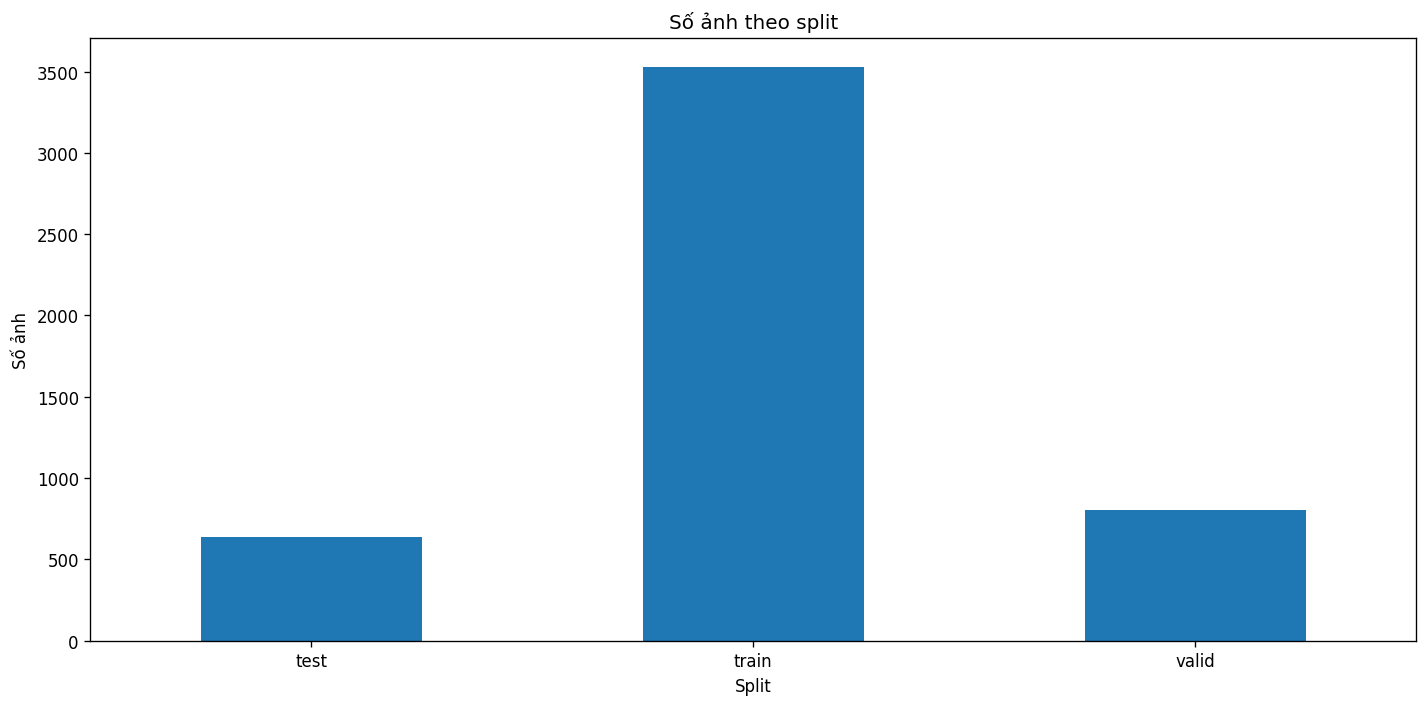

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/01_images_by_split.png


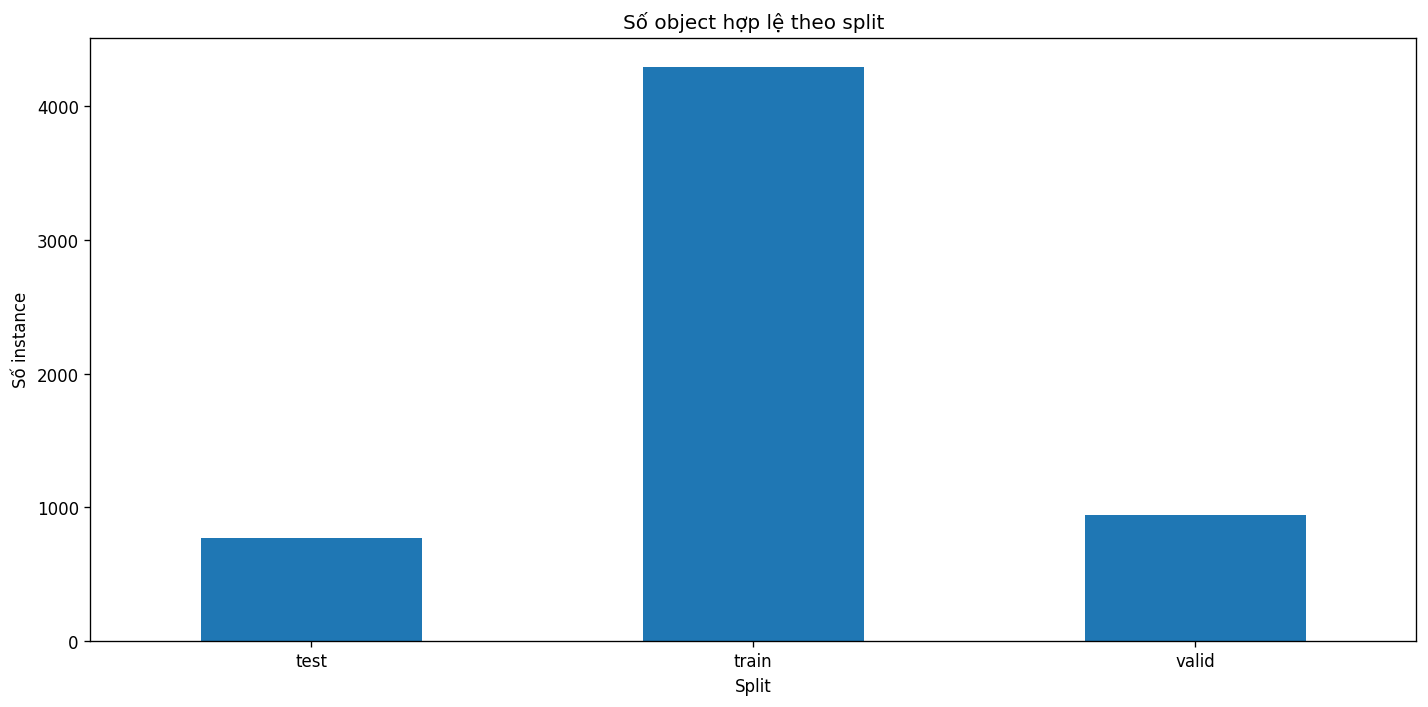

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/02_objects_by_split.png


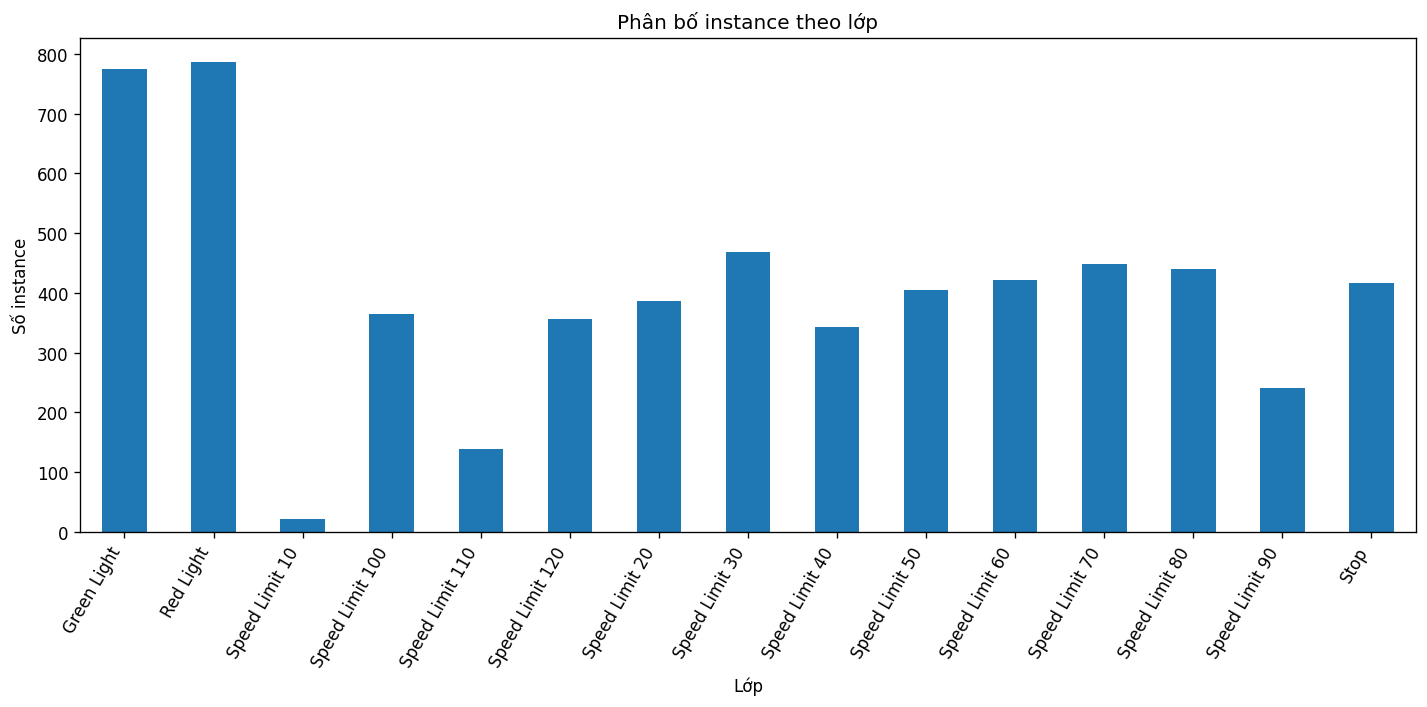

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/03_class_distribution_overall.png


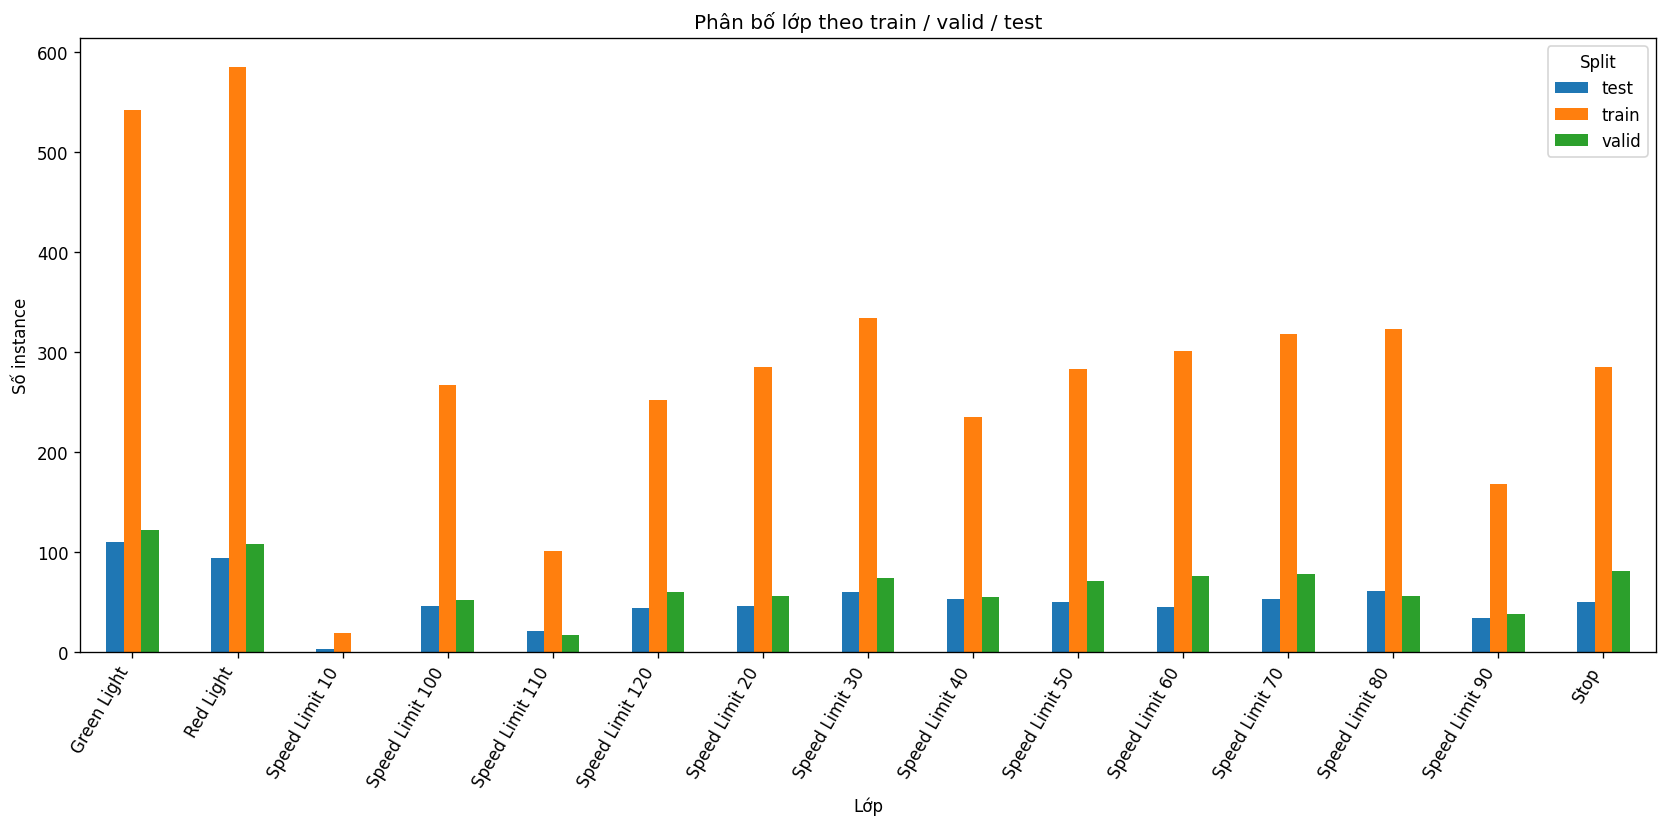

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/04_class_distribution_by_split.png


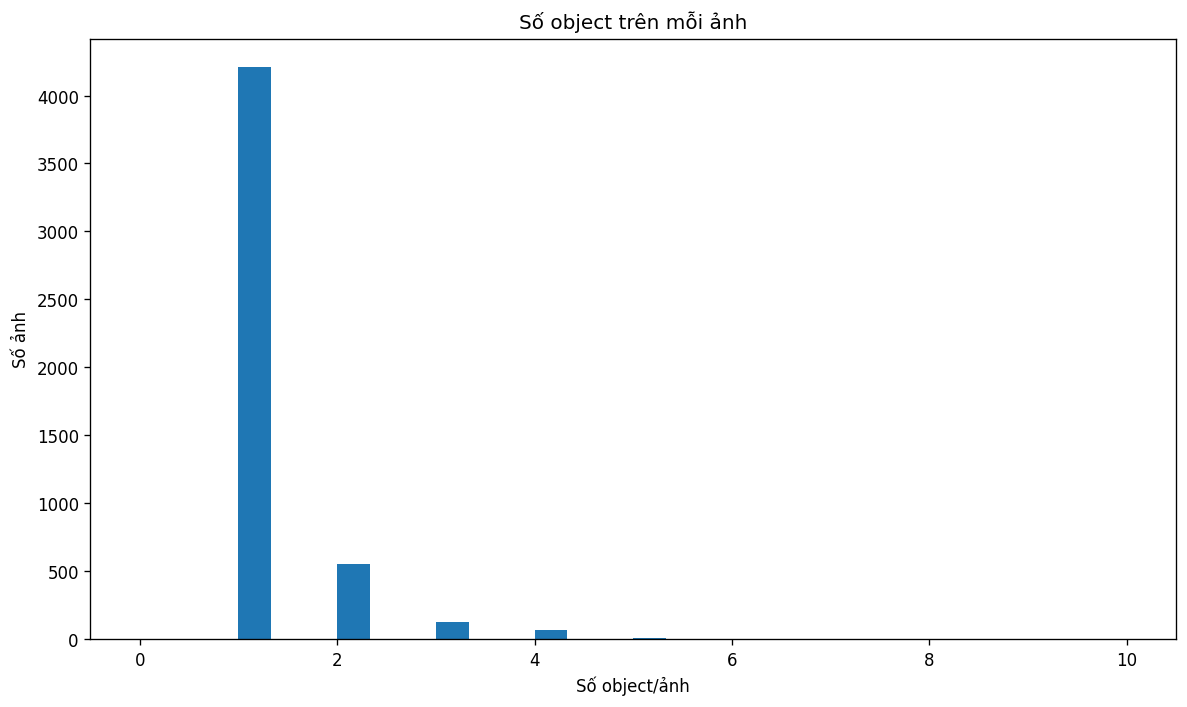

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/05_objects_per_image.png


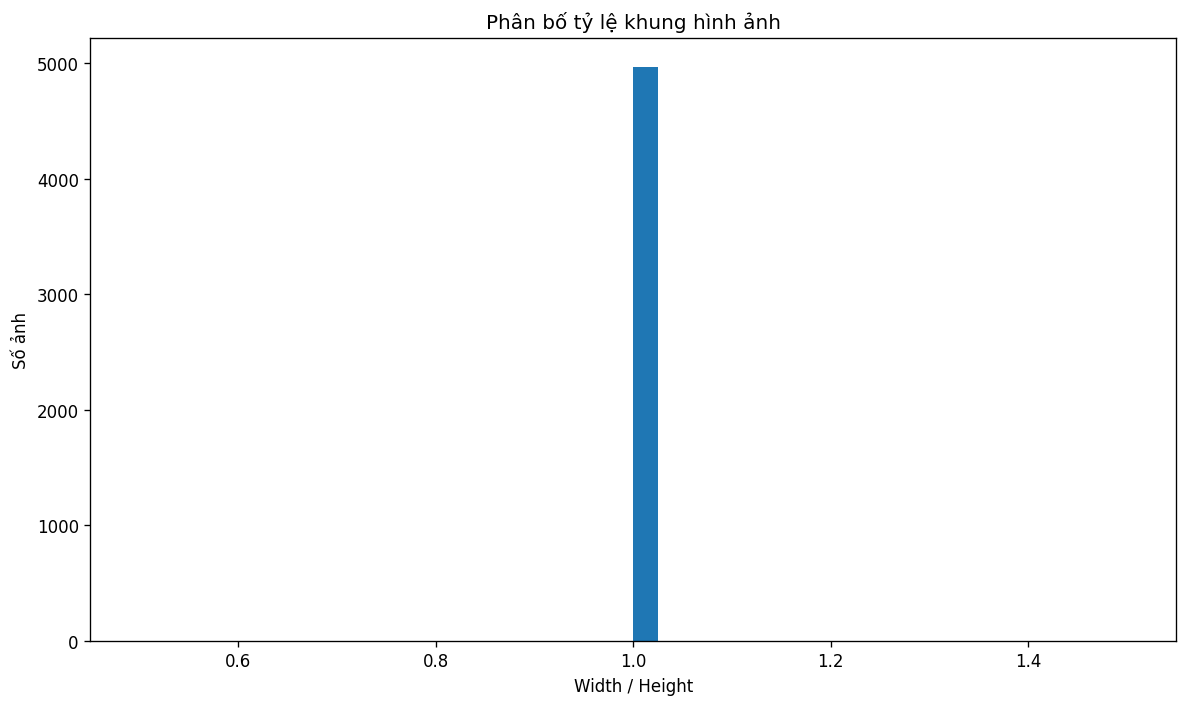

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/06_image_aspect_ratio.png


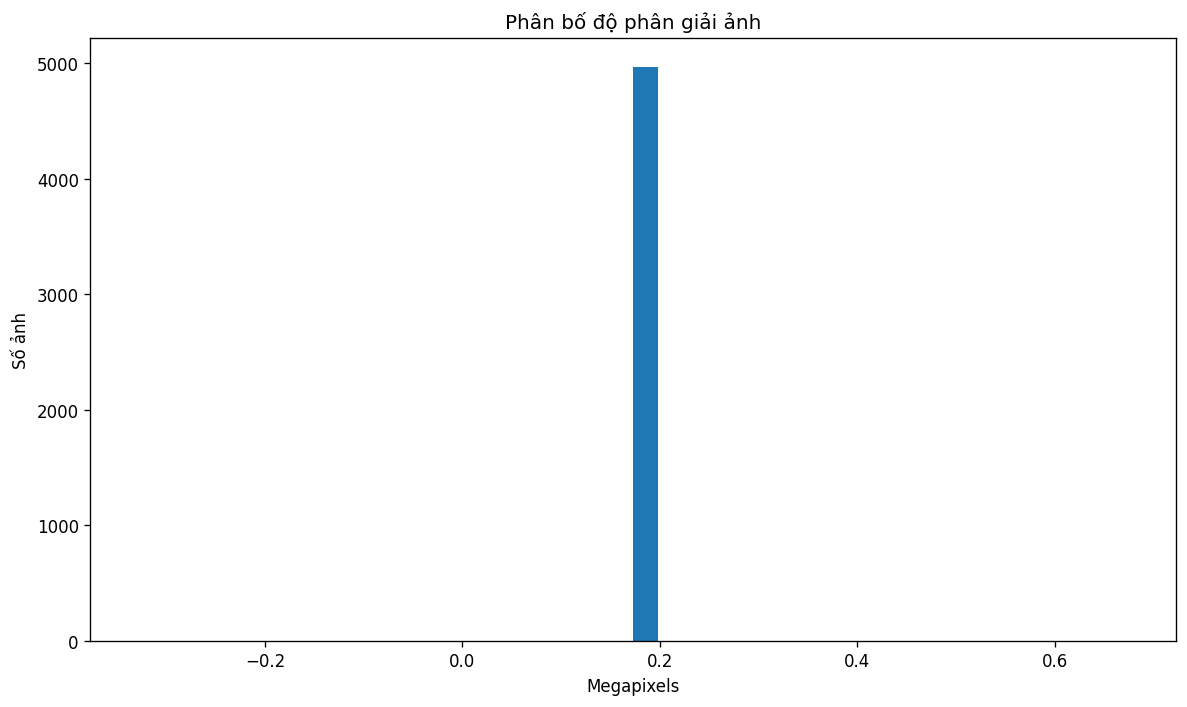

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/07_image_megapixels.png


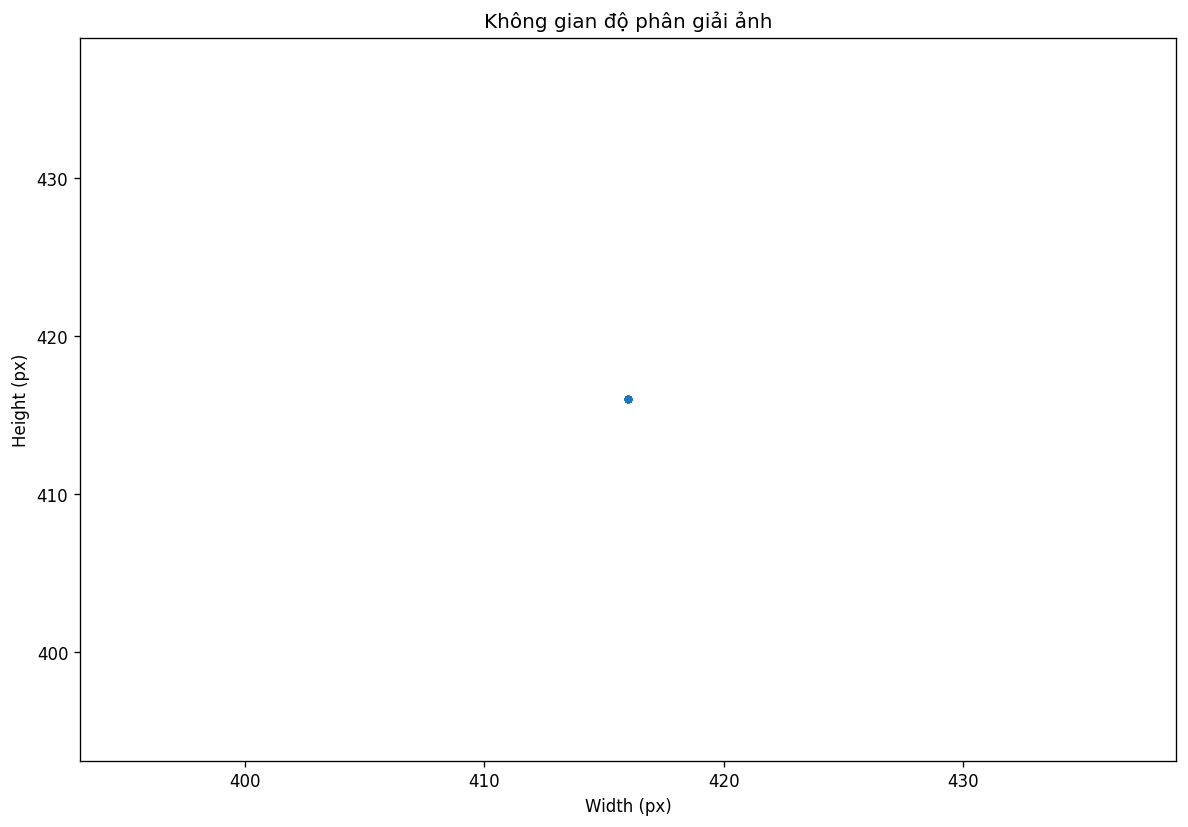

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/08_image_width_height_scatter.png


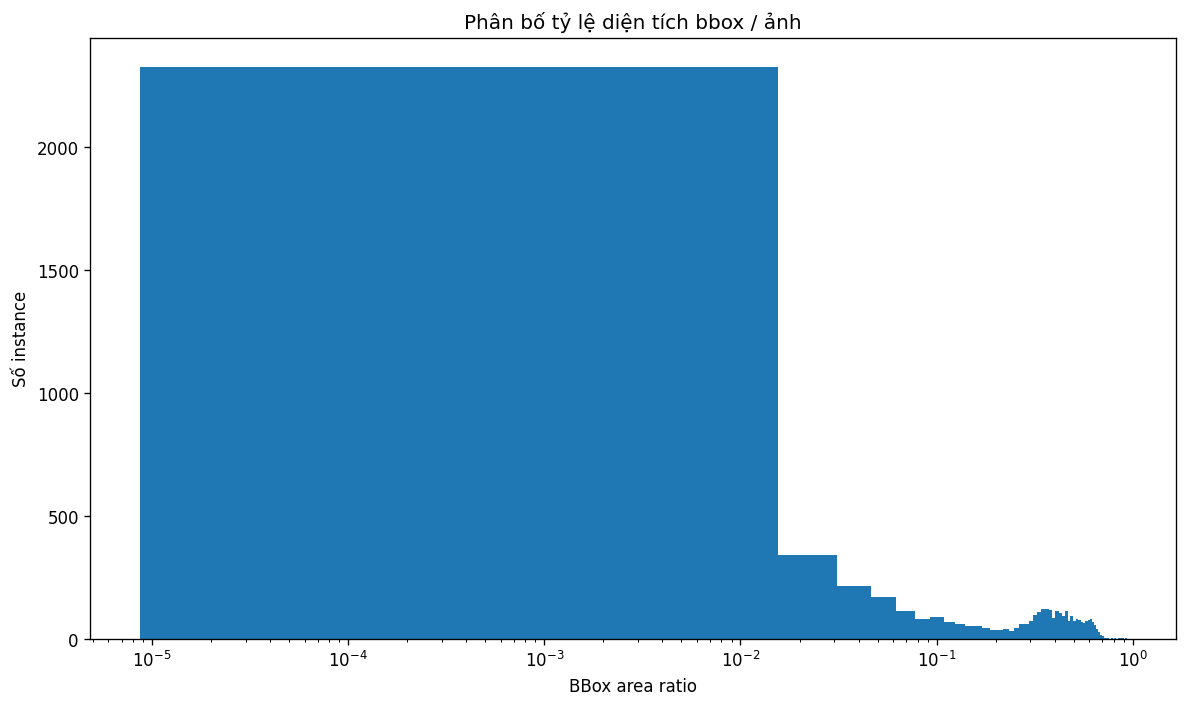

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/09_bbox_area_ratio_log.png


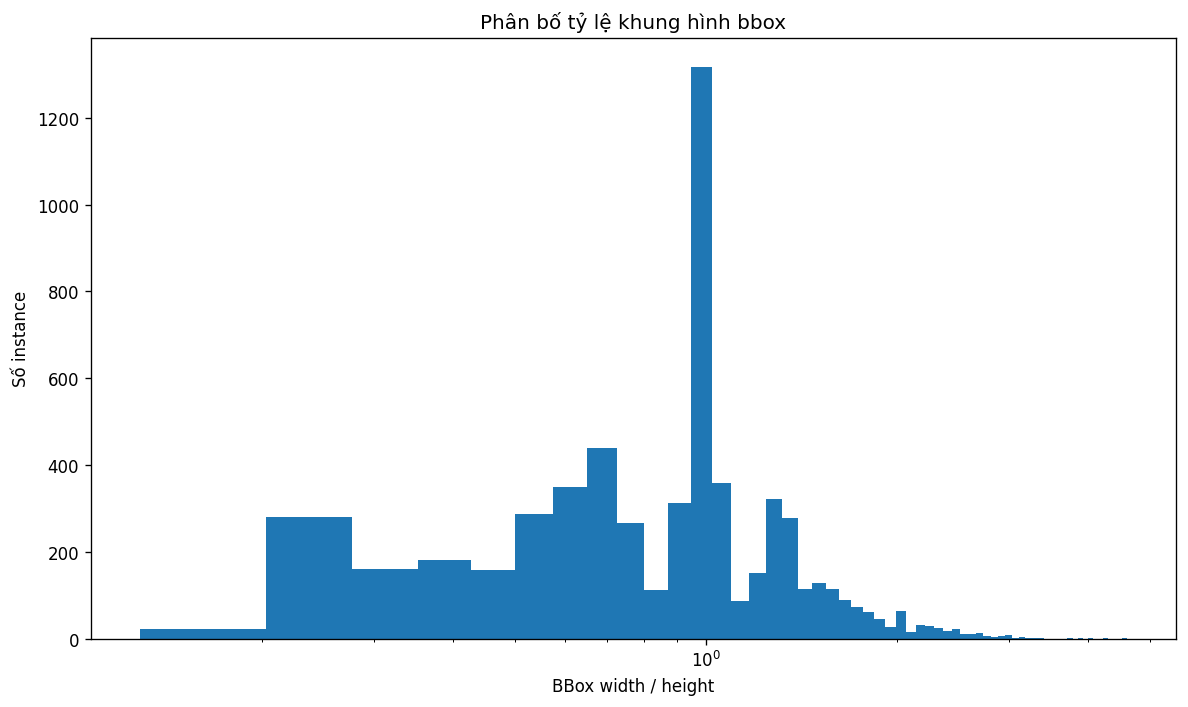

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/10_bbox_aspect_ratio_log.png


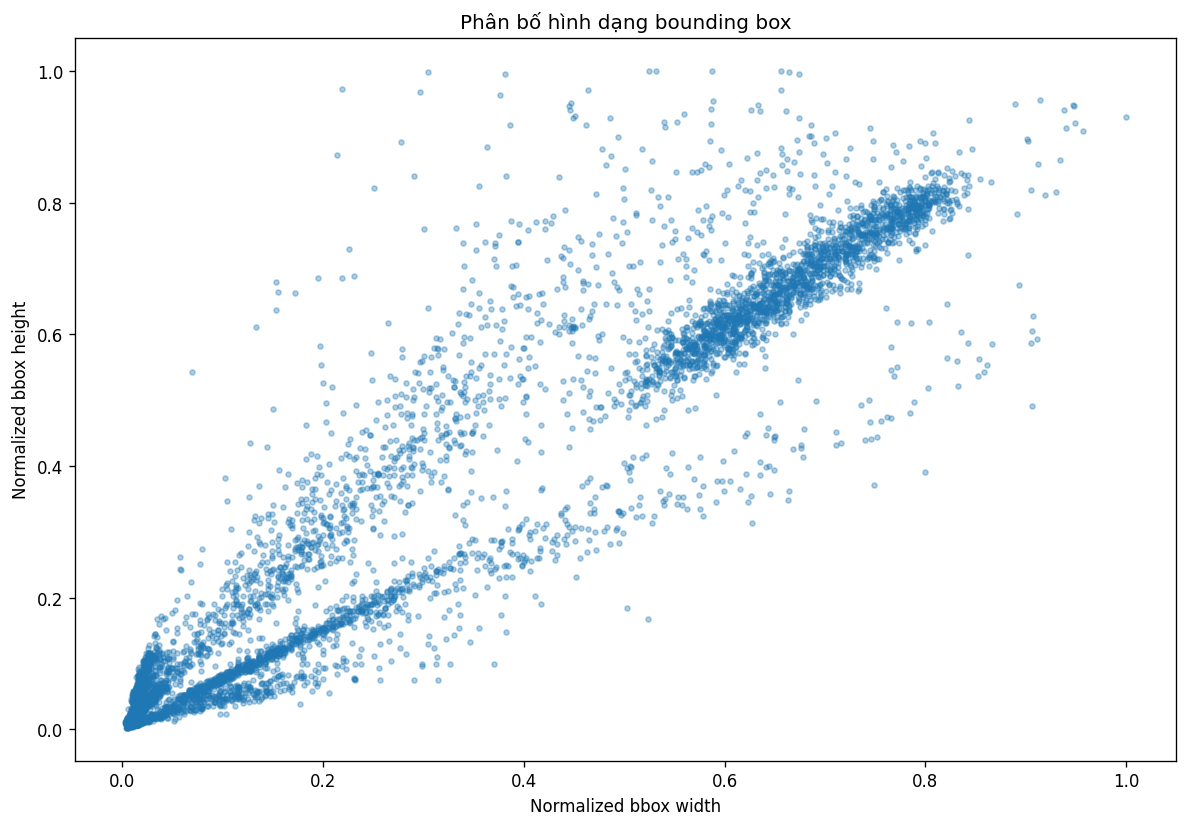

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/11_bbox_width_height_scatter.png


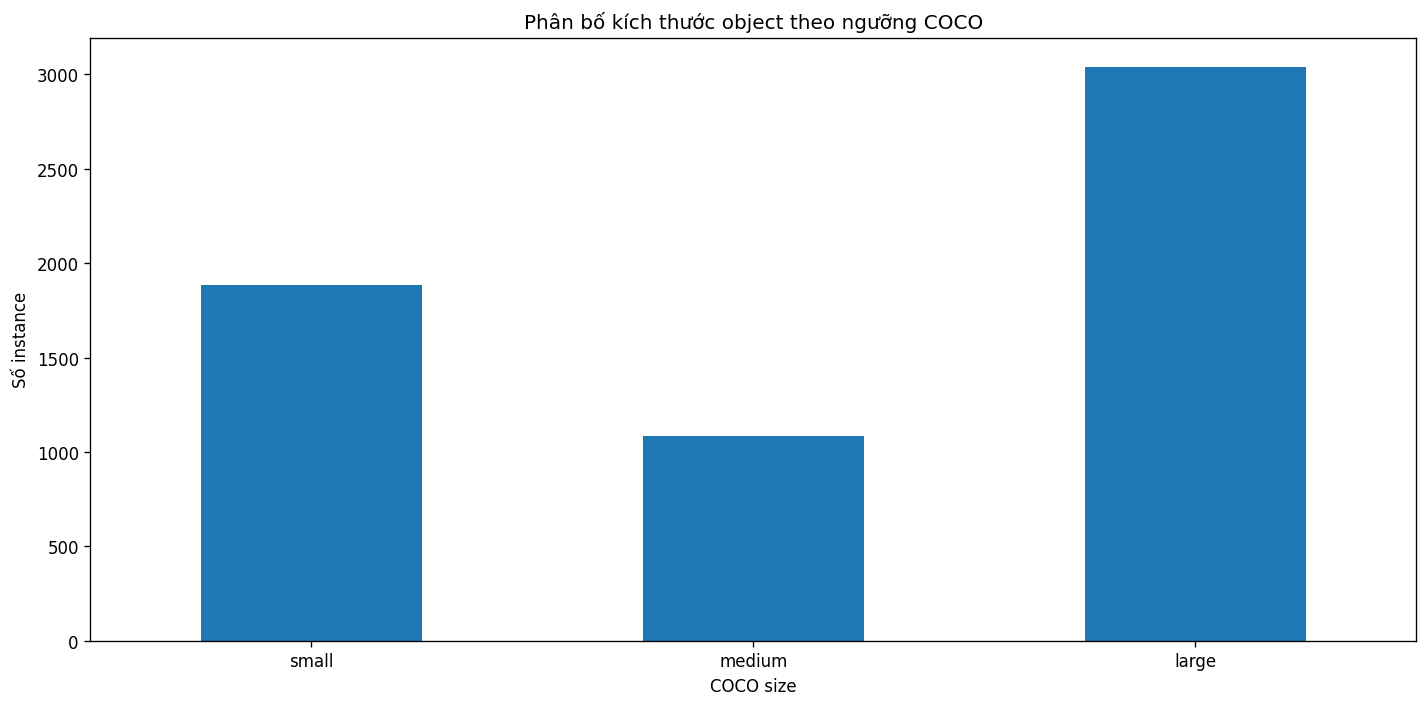

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/12_coco_size_distribution.png


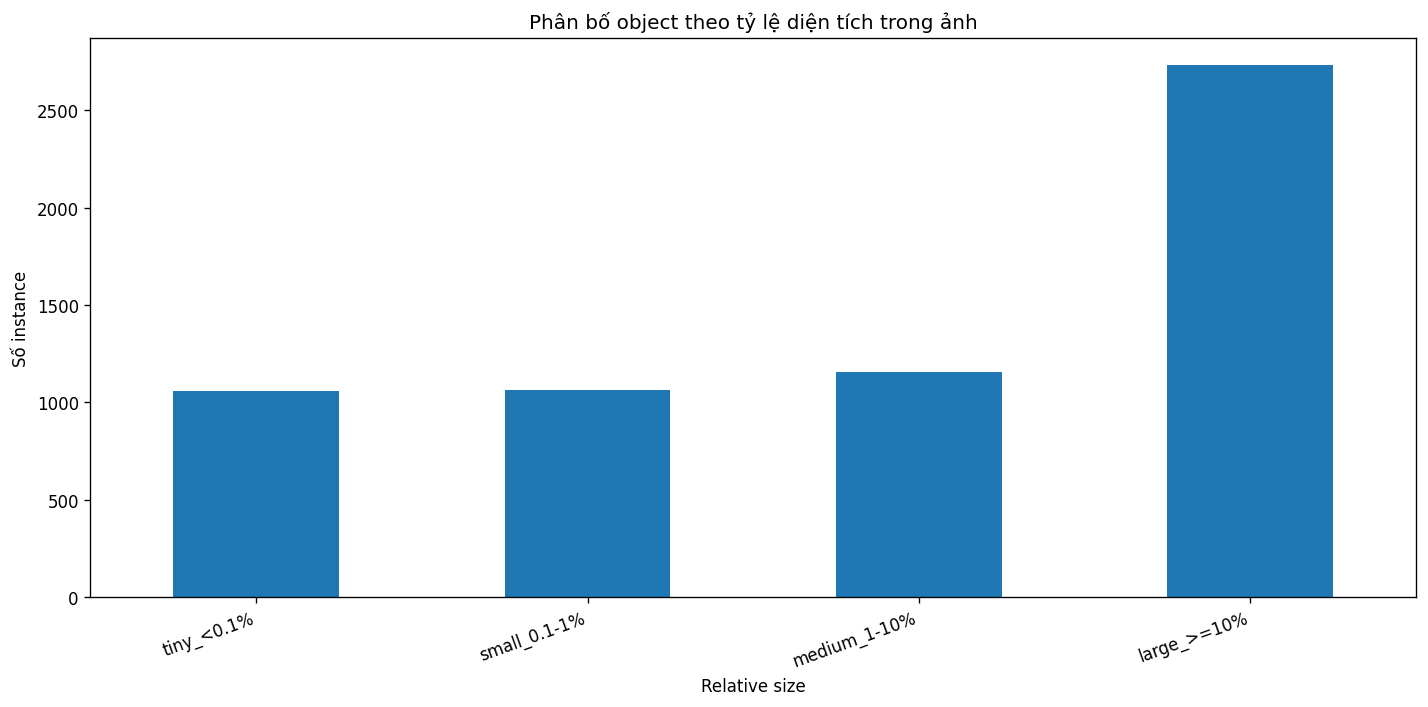

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/13_relative_size_distribution.png


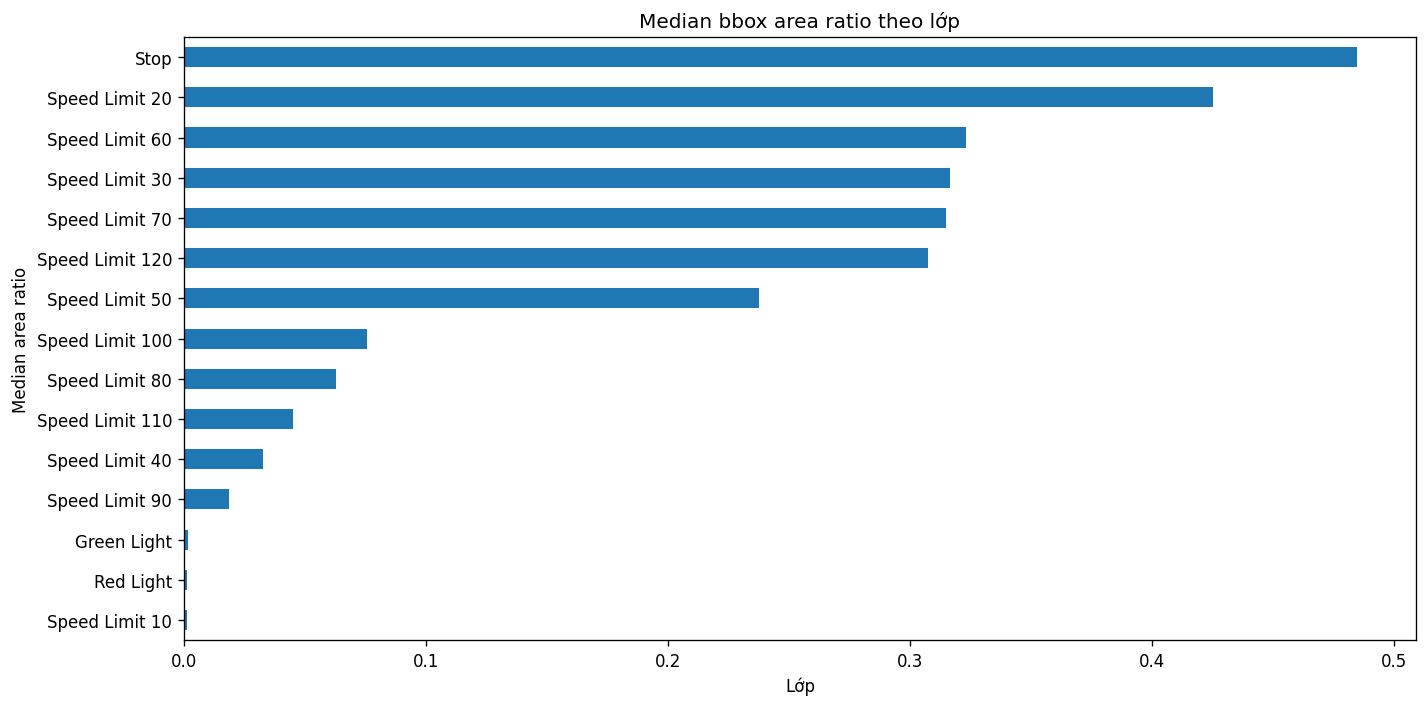

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/14_median_bbox_area_by_class.png


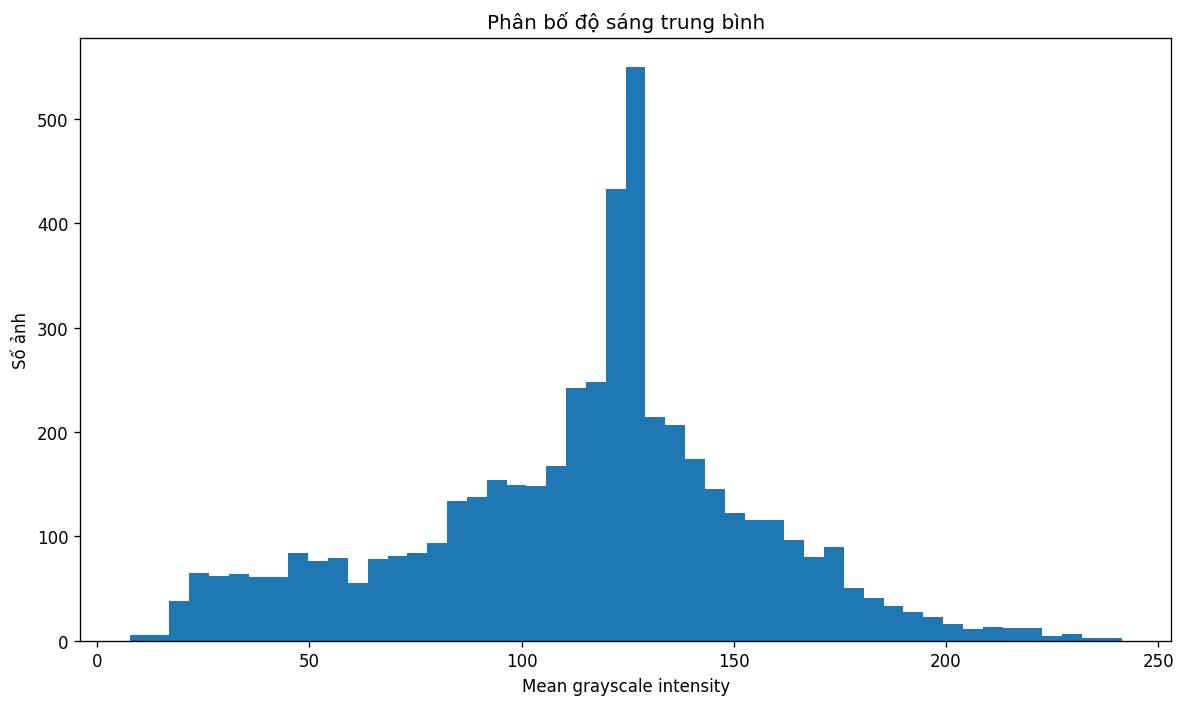

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/15_image_brightness.png


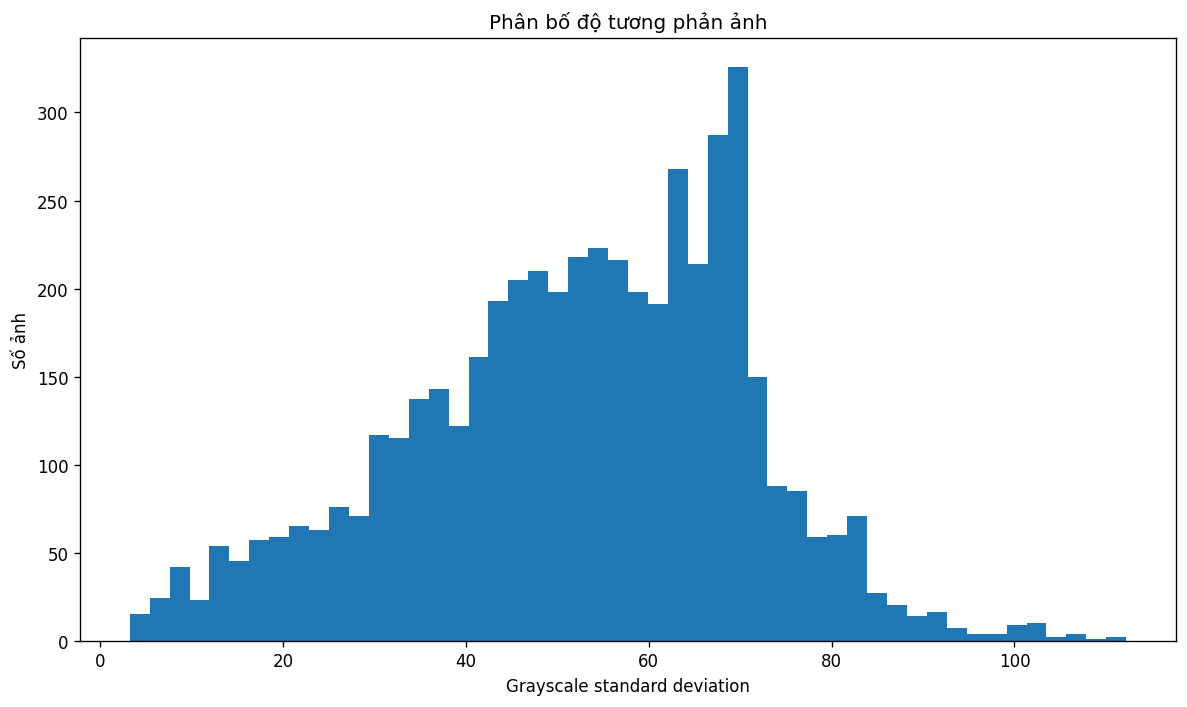

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/16_image_contrast.png


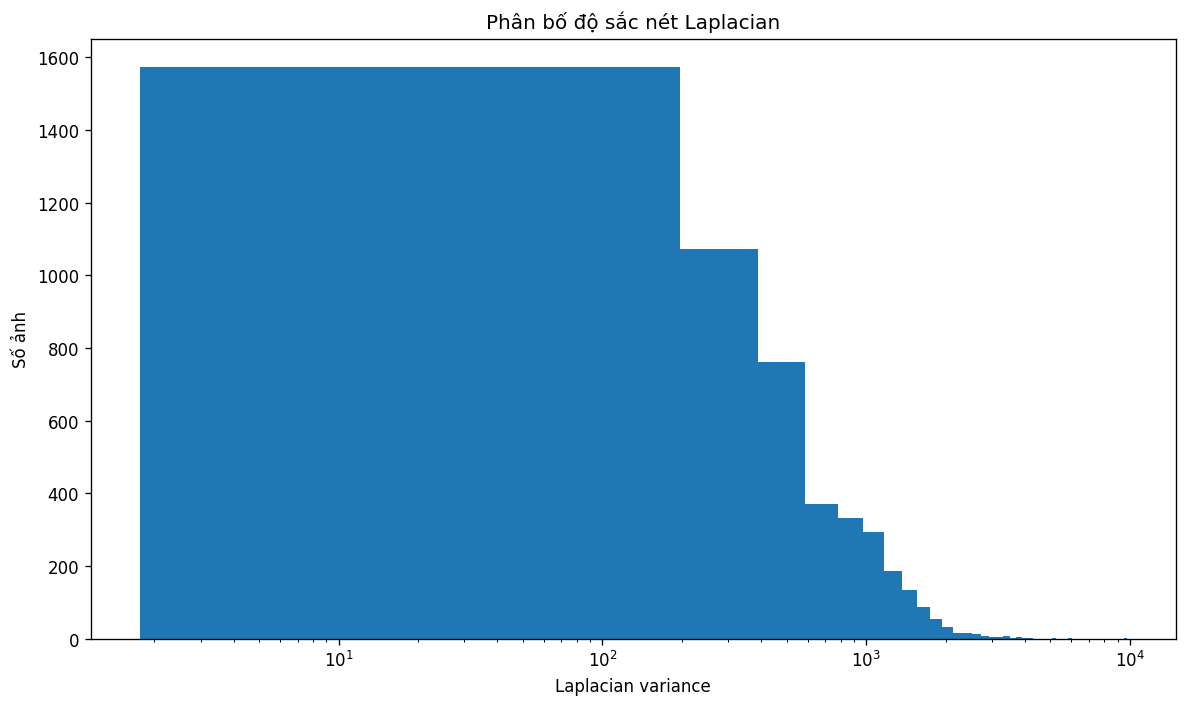

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/17_image_sharpness_log.png


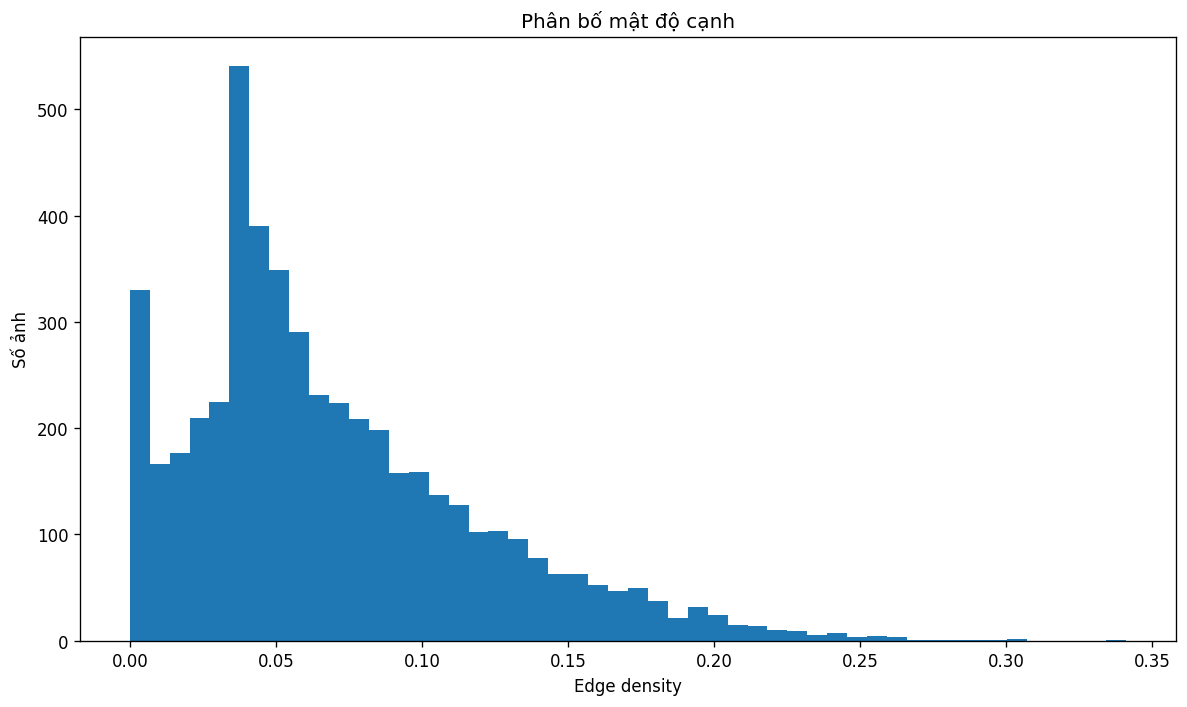

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/18_edge_density.png


In [13]:
# ==========================================================
# 7.2 Core charts
# ==========================================================
plot_bar(
    images_df.groupby('split').size(),
    'Số ảnh theo split', 'Split', 'Số ảnh', '01_images_by_split.png'
)

plot_bar(
    objects_df.groupby('split').size() if not objects_df.empty else pd.Series(dtype=float),
    'Số object hợp lệ theo split', 'Split', 'Số instance', '02_objects_by_split.png'
)

plot_bar(
    class_overall.set_index('class_name')['instances'],
    'Phân bố instance theo lớp', 'Lớp', 'Số instance', '03_class_distribution_overall.png', rotation=60
)

plt.figure(figsize=(14, 7))
class_pivot = class_counts_complete.pivot(index='class_name', columns='split', values='instances').fillna(0)
class_pivot.plot(kind='bar', ax=plt.gca())
plt.title('Phân bố lớp theo train / valid / test')
plt.xlabel('Lớp')
plt.ylabel('Số instance')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Split')
save_show('04_class_distribution_by_split.png')

plot_hist(images_df['n_valid_objects'], 'Số object trên mỗi ảnh', 'Số object/ảnh', 'Số ảnh', '05_objects_per_image.png', bins=30)
plot_hist(images_df['aspect_ratio'], 'Phân bố tỷ lệ khung hình ảnh', 'Width / Height', 'Số ảnh', '06_image_aspect_ratio.png', bins=40)
plot_hist(images_df['megapixels'], 'Phân bố độ phân giải ảnh', 'Megapixels', 'Số ảnh', '07_image_megapixels.png', bins=40)

plt.figure(figsize=(10, 7))
plt.scatter(images_df['width'], images_df['height'], s=12, alpha=0.45)
plt.title('Không gian độ phân giải ảnh')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
save_show('08_image_width_height_scatter.png')

if not objects_df.empty:
    plot_hist(objects_df['bbox_area_ratio'], 'Phân bố tỷ lệ diện tích bbox / ảnh', 'BBox area ratio', 'Số instance', '09_bbox_area_ratio_log.png', bins=60, log_x=True)
    plot_hist(objects_df['bbox_aspect_ratio'], 'Phân bố tỷ lệ khung hình bbox', 'BBox width / height', 'Số instance', '10_bbox_aspect_ratio_log.png', bins=60, log_x=True)

    plt.figure(figsize=(10, 7))
    sample = objects_df.sample(min(10000, len(objects_df)), random_state=SEED)
    plt.scatter(sample['bbox_width_norm'], sample['bbox_height_norm'], s=9, alpha=0.35)
    plt.title('Phân bố hình dạng bounding box')
    plt.xlabel('Normalized bbox width')
    plt.ylabel('Normalized bbox height')
    save_show('11_bbox_width_height_scatter.png')

    plot_bar(
        objects_df['coco_size_bin'].value_counts().reindex(['small', 'medium', 'large']).fillna(0),
        'Phân bố kích thước object theo ngưỡng COCO', 'COCO size', 'Số instance', '12_coco_size_distribution.png'
    )
    plot_bar(
        objects_df['relative_size_bin'].value_counts().reindex(['tiny_<0.1%', 'small_0.1-1%', 'medium_1-10%', 'large_>=10%']).fillna(0),
        'Phân bố object theo tỷ lệ diện tích trong ảnh', 'Relative size', 'Số instance', '13_relative_size_distribution.png', rotation=20
    )

    class_area = objects_df.groupby('class_name')['bbox_area_ratio'].median().sort_values()
    plot_bar(class_area, 'Median bbox area ratio theo lớp', 'Lớp', 'Median area ratio', '14_median_bbox_area_by_class.png', horizontal=True)

if CONFIG['COMPUTE_VISUAL_FEATURES']:
    for col, title, xlabel, filename in [
        ('brightness_mean', 'Phân bố độ sáng trung bình', 'Mean grayscale intensity', '15_image_brightness.png'),
        ('contrast_std', 'Phân bố độ tương phản ảnh', 'Grayscale standard deviation', '16_image_contrast.png'),
        ('sharpness_laplacian_var', 'Phân bố độ sắc nét Laplacian', 'Laplacian variance', '17_image_sharpness_log.png'),
        ('edge_density', 'Phân bố mật độ cạnh', 'Edge density', '18_edge_density.png'),
    ]:
        plot_hist(images_df[col], title, xlabel, 'Số ảnh', filename, bins=50, log_x=(col == 'sharpness_laplacian_var'))

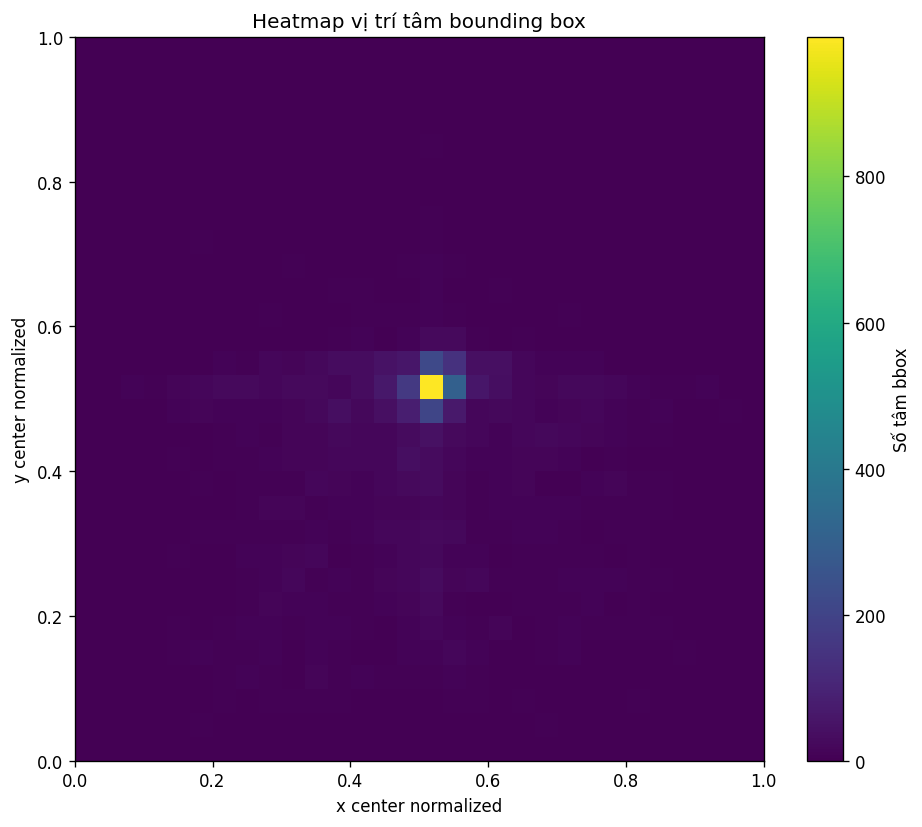

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/19_bbox_center_heatmap.png


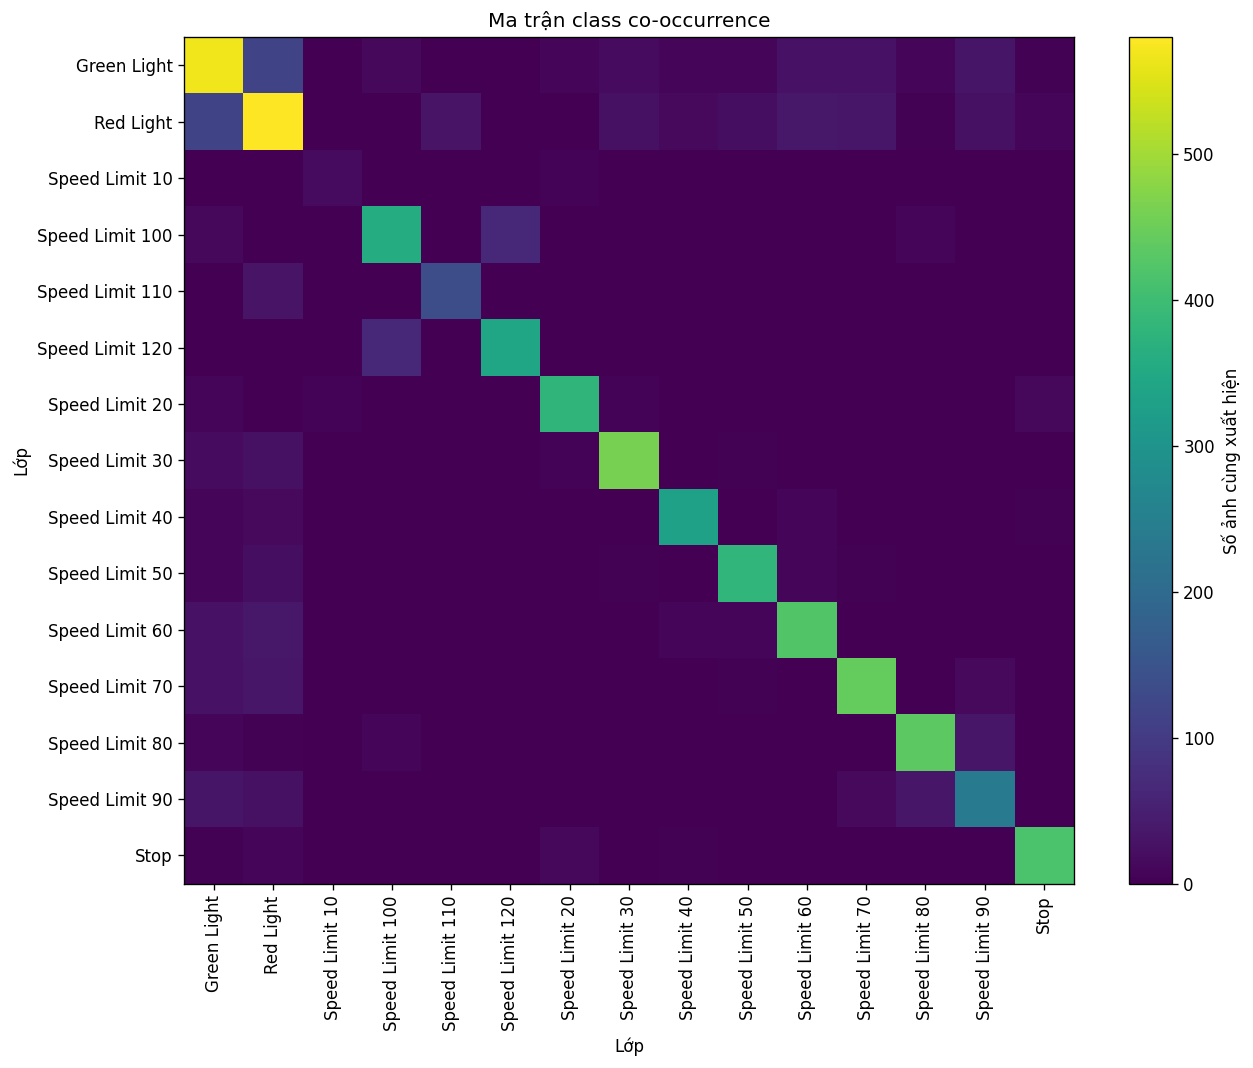

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/20_class_cooccurrence_heatmap.png


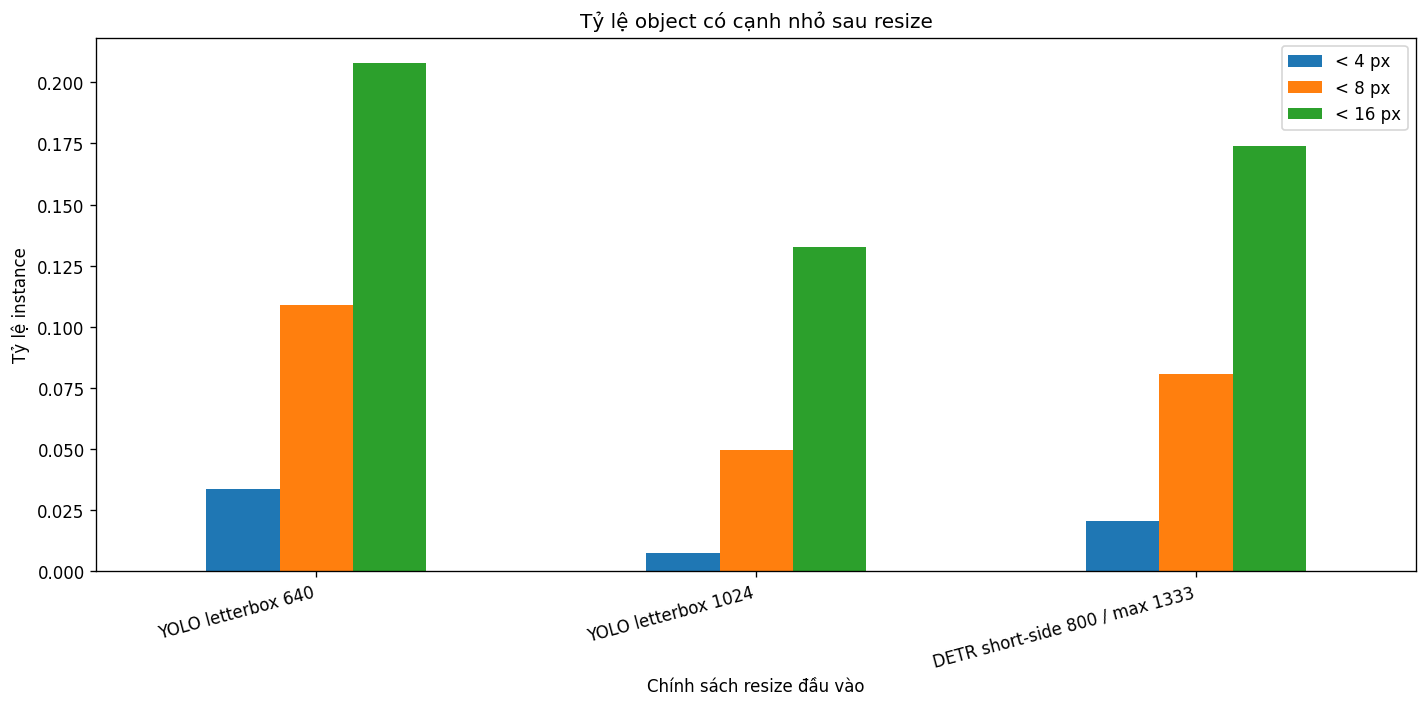

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/21_small_object_after_resize.png


In [14]:
# ==========================================================
# 7.3 Spatial heatmap, co-occurrence and model-size charts
# ==========================================================
if not objects_df.empty:
    heatmap, xedges, yedges = np.histogram2d(
        objects_df['x_center_norm'],
        objects_df['y_center_norm'],
        bins=30,
        range=[[0, 1], [0, 1]],
    )
    plt.figure(figsize=(8, 7))
    plt.imshow(heatmap.T, origin='lower', extent=[0, 1, 0, 1], aspect='auto')
    plt.colorbar(label='Số tâm bbox')
    plt.title('Heatmap vị trí tâm bounding box')
    plt.xlabel('x center normalized')
    plt.ylabel('y center normalized')
    save_show('19_bbox_center_heatmap.png')

plt.figure(figsize=(11, 9))
plt.imshow(cooccurrence_df.to_numpy(), aspect='auto')
plt.colorbar(label='Số ảnh cùng xuất hiện')
plt.xticks(range(NC), CLASS_NAMES, rotation=90)
plt.yticks(range(NC), CLASS_NAMES)
plt.title('Ma trận class co-occurrence')
plt.xlabel('Lớp')
plt.ylabel('Lớp')
save_show('20_class_cooccurrence_heatmap.png')

if not resolution_df.empty:
    resolution_plot = resolution_df.set_index('input_policy')[[
        'ratio_min_side_lt_4px', 'ratio_min_side_lt_8px', 'ratio_min_side_lt_16px'
    ]]
    plt.figure(figsize=(12, 6))
    resolution_plot.plot(kind='bar', ax=plt.gca())
    plt.title('Tỷ lệ object có cạnh nhỏ sau resize')
    plt.xlabel('Chính sách resize đầu vào')
    plt.ylabel('Tỷ lệ instance')
    plt.xticks(rotation=15, ha='right')
    plt.legend(['< 4 px', '< 8 px', '< 16 px'])
    save_show('21_small_object_after_resize.png')

In [15]:
# ==========================================================
# 7.4 Bounding-box visualization and contact sheets
# ==========================================================
def class_color(class_id):
    # Màu xác định theo class_id để ảnh tái lập được.
    rng = random.Random(1000 + int(class_id))
    return tuple(rng.randint(40, 230) for _ in range(3))


def draw_annotations(image_path, object_group, title_text=None):
    image = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(image)
    w, h = image.size
    line_width = max(2, int(round(max(w, h) / 400)))
    for _, row in object_group.iterrows():
        x1 = int(round(row['x1_norm'] * w))
        y1 = int(round(row['y1_norm'] * h))
        x2 = int(round(row['x2_norm'] * w))
        y2 = int(round(row['y2_norm'] * h))
        color = class_color(row['class_id'])
        draw.rectangle([x1, y1, x2, y2], outline=color, width=line_width)
        label = f"{int(row['class_id'])}: {row['class_name']}"
        text_bbox = draw.textbbox((x1, y1), label)
        tx2, ty2 = text_bbox[2], text_bbox[3]
        draw.rectangle([x1, max(0, y1 - (ty2 - y1) - 4), tx2 + 4, y1], fill=color)
        draw.text((x1 + 2, max(0, y1 - (ty2 - y1) - 2)), label, fill=(0, 0, 0))
    if title_text:
        draw.rectangle([0, 0, min(w, 850), 28], fill=(255, 255, 255))
        draw.text((6, 6), title_text[:120], fill=(0, 0, 0))
    return image


def save_visualization_rows(rows_df, prefix):
    saved = []
    for idx, row in rows_df.reset_index(drop=True).iterrows():
        group = objects_df[(objects_df['split'] == row['split']) & (objects_df['stem'] == row['stem'])]
        try:
            annotated = draw_annotations(
                row['image_path'], group,
                f"{row['split']} | {row['filename']} | objects={row['n_valid_objects']}"
            )
            annotated.thumbnail((900, 700), Image.Resampling.LANCZOS)
            out_path = SAMPLE_DIR / f'{prefix}_{idx:03d}_{row["split"]}_{row["stem"]}.jpg'
            annotated.save(out_path, quality=CONFIG['JPEG_QUALITY'])
            saved.append(out_path)
        except Exception as exc:
            print('Visualization error:', row['image_path'], exc)
    return saved


def make_contact_sheet(paths, output_path, columns=4, tile_size=(420, 300)):
    paths = list(paths)
    if not paths:
        return None
    rows = math.ceil(len(paths) / columns)
    sheet = Image.new('RGB', (columns * tile_size[0], rows * tile_size[1]), 'white')
    for idx, path in enumerate(paths):
        img = Image.open(path).convert('RGB')
        img.thumbnail((tile_size[0] - 10, tile_size[1] - 10), Image.Resampling.LANCZOS)
        x = (idx % columns) * tile_size[0] + (tile_size[0] - img.width) // 2
        y = (idx // columns) * tile_size[1] + (tile_size[1] - img.height) // 2
        sheet.paste(img, (x, y))
    sheet.save(output_path, quality=CONFIG['JPEG_QUALITY'])
    return output_path

positive_images = images_df[images_df['n_valid_objects'] > 0].copy()
random_rows = positive_images.sample(
    min(CONFIG['N_RANDOM_VISUALIZATIONS'], len(positive_images)),
    random_state=SEED
) if len(positive_images) else positive_images

random_paths = save_visualization_rows(random_rows, 'random')
random_sheet = make_contact_sheet(
    random_paths,
    SAMPLE_DIR / 'contact_sheet_random_samples.jpg',
    columns=CONFIG['CONTACT_SHEET_COLUMNS']
)
print('Random sample contact sheet:', random_sheet)

# Extreme cases: nhiều object, overlap cao, ảnh có object nhỏ nhất.
extreme_parts = []
if len(positive_images):
    extreme_parts.append(positive_images.nlargest(min(4, len(positive_images)), 'n_valid_objects'))
    extreme_parts.append(positive_images.nlargest(min(4, len(positive_images)), 'max_pairwise_iou'))
if not objects_df.empty:
    tiny_keys = objects_df.nsmallest(min(4, len(objects_df)), 'bbox_area_ratio')[['split', 'stem']].drop_duplicates()
    tiny_images = positive_images.merge(tiny_keys, on=['split', 'stem'], how='inner')
    extreme_parts.append(tiny_images)

extreme_rows = pd.concat(extreme_parts, ignore_index=True).drop_duplicates(['split', 'stem']).head(CONFIG['N_EXTREME_VISUALIZATIONS']) if extreme_parts else pd.DataFrame()
extreme_paths = save_visualization_rows(extreme_rows, 'extreme') if not extreme_rows.empty else []
extreme_sheet = make_contact_sheet(
    extreme_paths,
    SAMPLE_DIR / 'contact_sheet_extreme_cases.jpg',
    columns=CONFIG['CONTACT_SHEET_COLUMNS']
)
print('Extreme sample contact sheet:', extreme_sheet)

Random sample contact sheet: /kaggle/working/traffic_sign_yolo_pipeline/samples/contact_sheet_random_samples.jpg
Extreme sample contact sheet: /kaggle/working/traffic_sign_yolo_pipeline/samples/contact_sheet_extreme_cases.jpg


## 8. Phân cụm hình dạng bbox

YOLOv8 trở về sau và DETR đều có thể hoạt động theo hướng anchor-free, nên phân cụm này **không dùng để ép anchor**. Mục đích là mô tả các nhóm hình dạng/kích thước phổ biến của vật thể, từ đó hiểu độ đa dạng hình học và lựa chọn augmentation hợp lý.

,cluster_id,bbox_width_norm_center,bbox_height_norm_center,bbox_area_ratio_center,bbox_aspect_ratio_center,instances
6,6,0.025991,0.040084,0.001042,0.648394,1833
0,0,0.131608,0.108134,0.014231,1.217087,797
3,3,0.215255,0.243847,0.052489,0.882746,563
2,2,0.445747,0.307279,0.136969,1.450625,195
7,7,0.302947,0.482526,0.146180,0.627835,310
5,5,0.572459,0.576215,0.329859,0.993481,742
8,8,0.458553,0.782816,0.358963,0.585773,155
1,1,0.669877,0.677556,0.453879,0.988666,747
4,4,0.767275,0.788993,0.605375,0.972475,670


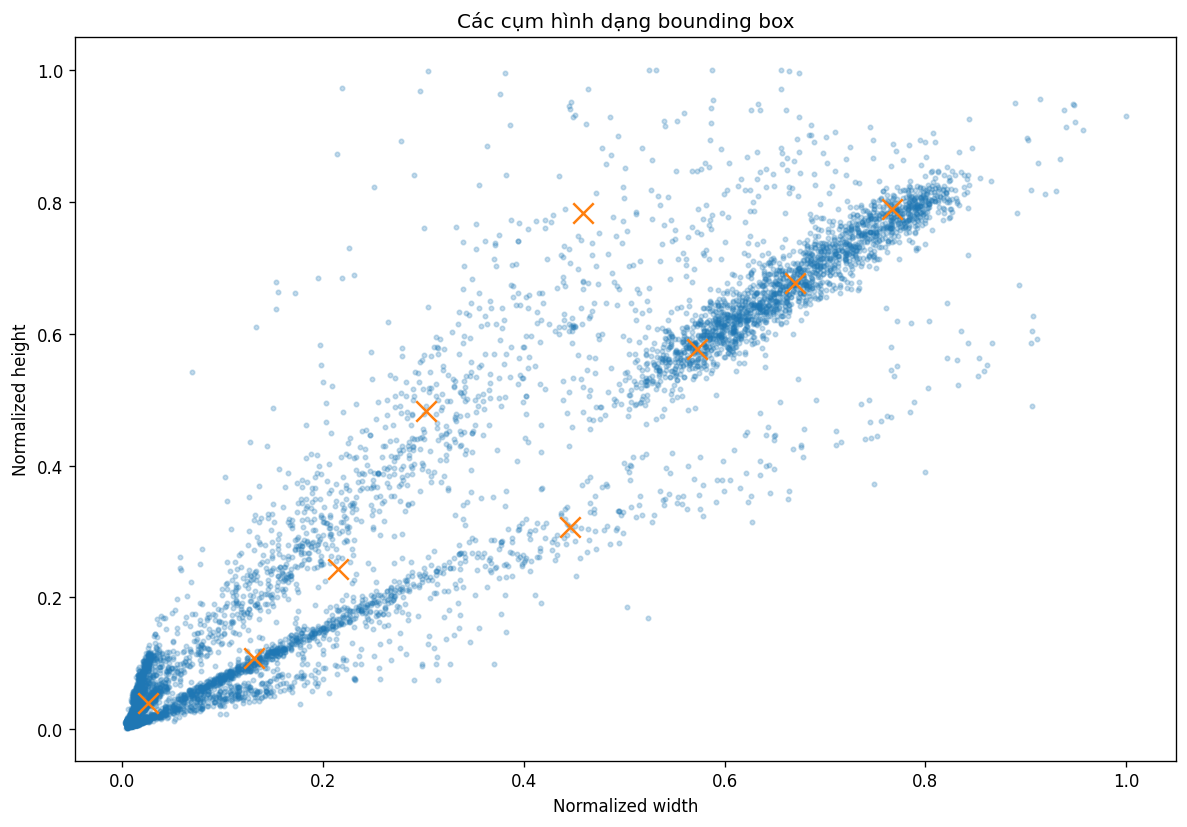

Saved: /kaggle/working/traffic_sign_yolo_pipeline/figures/22_bbox_shape_clusters.png


In [16]:
# ==========================================================
# 8.1 K-means bbox shape clusters
# ==========================================================
shape_clusters_df = pd.DataFrame()
if SKLEARN_AVAILABLE and len(objects_df) >= 3:
    features = objects_df[['bbox_width_norm', 'bbox_height_norm']].to_numpy(dtype=float)
    n_clusters = min(9, max(2, int(round(math.sqrt(len(features) / 2)))))
    n_clusters = min(n_clusters, len(features))
    model = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
    labels = model.fit_predict(features)
    centers = model.cluster_centers_
    counts = Counter(labels)
    rows = []
    for cluster_id, (bw, bh) in enumerate(centers):
        rows.append({
            'cluster_id': cluster_id,
            'bbox_width_norm_center': float(bw),
            'bbox_height_norm_center': float(bh),
            'bbox_area_ratio_center': float(bw * bh),
            'bbox_aspect_ratio_center': float(bw / bh) if bh > 0 else np.nan,
            'instances': int(counts[cluster_id]),
        })
    shape_clusters_df = pd.DataFrame(rows).sort_values('bbox_area_ratio_center')
    shape_clusters_df.to_csv(TABLE_DIR / 'bbox_shape_clusters.csv', index=False)
    display(shape_clusters_df)

    plt.figure(figsize=(10, 7))
    sample_idx = np.random.RandomState(SEED).choice(len(features), size=min(10000, len(features)), replace=False)
    plt.scatter(features[sample_idx, 0], features[sample_idx, 1], s=7, alpha=0.25)
    plt.scatter(centers[:, 0], centers[:, 1], s=150, marker='x')
    plt.title('Các cụm hình dạng bounding box')
    plt.xlabel('Normalized width')
    plt.ylabel('Normalized height')
    save_show('22_bbox_shape_clusters.png')
else:
    print('Bỏ qua K-means vì scikit-learn không khả dụng hoặc quá ít bbox.')

## 9. Chuẩn hóa dữ liệu cho YOLO và chuyển sang COCO cho DETR

### YOLO

Notebook tạo `model_ready/data_eda.yaml` trỏ tới các split ảnh đã dò được và giữ nguyên class mapping.

### DETR

Nhiều implementation DETR dùng COCO-style annotations. Notebook chuyển mỗi split thành JSON gồm:

- `images`: id, file_name, width, height
- `annotations`: bbox dạng pixel `[x_min, y_min, width, height]`, area, category_id, iscrowd
- `categories`: 15 lớp

`category_id` trong COCO được đặt từ **1 đến 15**; bảng `coco_category_mapping.csv` lưu ánh xạ với YOLO class ID từ 0 đến 14.

In [17]:
# ==========================================================
# 9.1 Export clean YOLO YAML
# ==========================================================
yolo_yaml = {
    'path': '/',
    'train': str(SPLIT_IMAGE_DIRS.get('train', '')),
    'val': str(SPLIT_IMAGE_DIRS.get('valid', '')),
    'test': str(SPLIT_IMAGE_DIRS.get('test', '')),
    'nc': NC,
    'names': CLASS_NAMES,
}
with open(MODEL_DIR / 'data_eda.yaml', 'w', encoding='utf-8') as f:
    yaml.safe_dump(yolo_yaml, f, sort_keys=False, allow_unicode=True)

print((MODEL_DIR / 'data_eda.yaml').read_text(encoding='utf-8'))

path: /
train: /kaggle/input/datasets/pkdarabi/cardetection/car/train/images
val: /kaggle/input/datasets/pkdarabi/cardetection/car/valid/images
test: /kaggle/input/datasets/pkdarabi/cardetection/car/test/images
nc: 15
names:
- Green Light
- Red Light
- Speed Limit 10
- Speed Limit 100
- Speed Limit 110
- Speed Limit 120
- Speed Limit 20
- Speed Limit 30
- Speed Limit 40
- Speed Limit 50
- Speed Limit 60
- Speed Limit 70
- Speed Limit 80
- Speed Limit 90
- Stop



In [18]:
# ==========================================================
# 9.2 Convert valid YOLO boxes to COCO JSON for DETR
# ==========================================================
coco_mapping = pd.DataFrame({
    'yolo_class_id': range(NC),
    'coco_category_id': range(1, NC + 1),
    'class_name': CLASS_NAMES,
})
coco_mapping.to_csv(MODEL_DIR / 'coco_category_mapping.csv', index=False)


def split_to_coco(split):
    split_images = images_df[images_df['split'] == split].reset_index(drop=True)
    image_id_map = {}
    coco_images = []
    coco_annotations = []
    annotation_id = 1

    for image_id, row in split_images.iterrows():
        image_id = int(image_id + 1)
        key = (row['split'], row['stem'])
        image_id_map[key] = image_id
        coco_images.append({
            'id': image_id,
            'file_name': row['filename'],
            'width': int(row['width']),
            'height': int(row['height']),
        })

    split_objects = objects_df[objects_df['split'] == split]
    for _, obj in split_objects.iterrows():
        image_id = image_id_map[(obj['split'], obj['stem'])]
        x = float(obj['x1_norm'] * obj['image_width'])
        y = float(obj['y1_norm'] * obj['image_height'])
        w = float(obj['bbox_width_px'])
        h = float(obj['bbox_height_px'])
        coco_annotations.append({
            'id': annotation_id,
            'image_id': image_id,
            'category_id': int(obj['class_id']) + 1,
            'bbox': [x, y, w, h],
            'area': float(w * h),
            'iscrowd': 0,
        })
        annotation_id += 1

    coco = {
        'info': {
            'description': 'Traffic Signs Detection converted from YOLO to COCO for DETR',
            'dataset_source': 'pkdarabi/cardetection',
            'date_created_utc': datetime.now(timezone.utc).isoformat(),
        },
        'licenses': [],
        'images': coco_images,
        'annotations': coco_annotations,
        'categories': [
            {'id': i + 1, 'name': name, 'supercategory': 'traffic_sign_or_light'}
            for i, name in enumerate(CLASS_NAMES)
        ],
    }
    output_path = COCO_DIR / f'instances_{split}.json'
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(coco, f, ensure_ascii=False, indent=2)
    return {
        'split': split,
        'json_path': str(output_path),
        'images': len(coco_images),
        'annotations': len(coco_annotations),
        'categories': len(coco['categories']),
    }

coco_export_summary = pd.DataFrame([split_to_coco(split) for split in sorted(images_df['split'].unique())])
coco_export_summary.to_csv(MODEL_DIR / 'coco_export_summary.csv', index=False)
display(coco_export_summary)

,split,json_path,images,annotations,categories
0,test,/kaggle/working/traffic_sign_yolo_pipeline/coc...,638,770,15
1,train,/kaggle/working/traffic_sign_yolo_pipeline/coc...,3530,4298,15
2,valid,/kaggle/working/traffic_sign_yolo_pipeline/coc...,801,944,15


## 10. Diễn giải EDA và xây dựng khuyến nghị

Phần này không huấn luyện model; nó biến kết quả EDA thành các quyết định thiết kế có căn cứ.

| Khía cạnh | YOLO | DETR |
|---|---|---|
| Tốc độ | Phù hợp triển khai thời gian thực | Thường chậm hơn, tùy backbone/biến thể |
| Small object | Cần độ phân giải cao, multi-scale/P2 head hoặc crop | DETR nguyên bản có thể yếu với vật nhỏ; Deformable DETR thường phù hợp hơn |
| Class imbalance | Có thể dùng oversampling/copy-paste/focal-like loss tùy implementation | Có thể điều chỉnh sampling, augmentation và class cost |
| Định dạng dữ liệu | Dùng trực tiếp YOLO TXT | Dùng COCO JSON đã xuất |
| Nhiều object/ảnh | Tốt, tối ưu inference | Set prediction tự nhiên, không cần NMS ở DETR chuẩn |
| Huấn luyện | Hội tụ nhanh hơn | DETR nguyên bản cần lịch train dài; Deformable DETR hội tụ tốt hơn |

Các khuyến nghị cuối cùng được tạo tự động từ số liệu thật ở cell tiếp theo.

In [19]:
# ==========================================================
# 10.1 Automatic scientific findings and recommendations
# ==========================================================
def pct(x):
    return 'N/A' if pd.isna(x) else f'{100 * x:.2f}%'


total_images = len(images_df)
total_objects = len(objects_df)
background_ratio = float(images_df['is_background_image'].mean()) if len(images_df) else np.nan
missing_labels = int((~images_df['label_exists']).sum())
invalid_objects = int(images_df['n_invalid_objects'].sum())
malformed_lines = int(images_df['n_malformed_lines'].sum())

if not class_overall.empty and class_overall['instances'].sum() > 0:
    dominant = class_overall.sort_values('instances', ascending=False).iloc[0]
    rare_nonzero = class_overall[class_overall['instances'] > 0].sort_values('instances').iloc[0]
else:
    dominant = {'class_name': 'N/A', 'instances': 0}
    rare_nonzero = {'class_name': 'N/A', 'instances': 0}

overall_imbalance = imbalance_df[imbalance_df['split'] == 'overall'].iloc[0]
small_coco_ratio = float((objects_df['coco_size_bin'] == 'small').mean()) if len(objects_df) else np.nan
tiny_relative_ratio = float((objects_df['relative_size_bin'] == 'tiny_<0.1%').mean()) if len(objects_df) else np.nan
border_ratio = float(objects_df['touches_border'].mean()) if len(objects_df) else np.nan
yolo640_lt8 = float(resolution_df.loc[resolution_df['input_policy'] == 'YOLO letterbox 640', 'ratio_min_side_lt_8px'].iloc[0]) if not resolution_df.empty else np.nan
detr_lt8 = float(resolution_df.loc[resolution_df['input_policy'] == 'DETR short-side 800 / max 1333', 'ratio_min_side_lt_8px'].iloc[0]) if not resolution_df.empty else np.nan
max_jsd = float(split_shift_df['jensen_shannon_divergence_bits'].max()) if not split_shift_df.empty else np.nan
exact_cross_split_duplicate_groups = int(cross_split_md5['md5'].nunique()) if not cross_split_md5.empty else 0

recommendations = []
if yolo640_lt8 > 0.10:
    recommendations.append('Tỷ lệ object có cạnh nhỏ dưới 8 px ở YOLO-640 khá cao: ưu tiên imgsz 896/1024, P2 head, multi-scale hoặc crop/tiling.')
else:
    recommendations.append('Độ phân giải 640 có thể là baseline hợp lý; vẫn cần kiểm tra mAP_small trước khi kết luận.')
if overall_imbalance['imbalance_ratio_max_over_min_positive'] > 5:
    recommendations.append('Mất cân bằng lớp đáng kể: dùng class-aware sampling, oversampling lớp hiếm và theo dõi AP từng lớp thay vì chỉ mAP tổng.')
if exact_cross_split_duplicate_groups > 0:
    recommendations.append('Có exact duplicate xuyên split: cần loại bỏ trước huấn luyện để tránh data leakage.')
if max_jsd > 0.10:
    recommendations.append('Phân bố lớp giữa các split có dịch chuyển đáng chú ý: báo cáo metric theo lớp và cân nhắc chia lại split theo stratification nhóm ảnh.')
if small_coco_ratio > 0.50:
    recommendations.append('Phần lớn object thuộc nhóm COCO-small: Deformable DETR phù hợp hơn DETR nguyên bản; YOLO cần neck/head đa tỷ lệ mạnh.')
recommendations.append('Không dùng horizontal flip một cách mặc định cho biển báo có ý nghĩa hướng; cần kiểm tra augmentation theo ngữ nghĩa lớp.')
recommendations.append('Đánh giá bằng mAP50-95, AP_small/medium/large, precision, recall, FPS và confusion matrix theo lớp.')

findings = {
    'dataset': 'pkdarabi/cardetection',
    'task': 'traffic sign and traffic light object detection',
    'n_classes': NC,
    'total_images_scanned': total_images,
    'total_valid_objects': total_objects,
    'background_image_ratio': background_ratio,
    'missing_label_files': missing_labels,
    'invalid_objects': invalid_objects,
    'malformed_label_lines': malformed_lines,
    'dominant_class': {'name': str(dominant['class_name']), 'instances': int(dominant['instances'])},
    'rarest_nonzero_class': {'name': str(rare_nonzero['class_name']), 'instances': int(rare_nonzero['instances'])},
    'imbalance_ratio': float(overall_imbalance['imbalance_ratio_max_over_min_positive']),
    'normalized_class_entropy': float(overall_imbalance['normalized_entropy']),
    'class_gini': float(overall_imbalance['gini']),
    'coco_small_object_ratio': small_coco_ratio,
    'relative_tiny_object_ratio': tiny_relative_ratio,
    'border_touch_ratio': border_ratio,
    'yolo640_min_side_lt_8px_ratio': yolo640_lt8,
    'detr800_min_side_lt_8px_ratio': detr_lt8,
    'maximum_split_js_divergence_bits': max_jsd,
    'exact_cross_split_duplicate_groups': exact_cross_split_duplicate_groups,
    'recommendations': recommendations,
}

with open(OUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(findings, f, ensure_ascii=False, indent=2)

print(json.dumps(findings, ensure_ascii=False, indent=2))

{
  "dataset": "pkdarabi/cardetection",
  "task": "traffic sign and traffic light object detection",
  "n_classes": 15,
  "total_images_scanned": 4969,
  "total_valid_objects": 6012,
  "background_image_ratio": 0.0008049909438518816,
  "missing_label_files": 0,
  "invalid_objects": 0,
  "malformed_label_lines": 0,
  "dominant_class": {
    "name": "Red Light",
    "instances": 787
  },
  "rarest_nonzero_class": {
    "name": "Speed Limit 10",
    "instances": 22
  },
  "imbalance_ratio": 35.77272727272727,
  "normalized_class_entropy": 0.9528278903793151,
  "class_gini": 0.24670658682634738,
  "coco_small_object_ratio": 0.31370592149035265,
  "relative_tiny_object_ratio": 0.1763140385894877,
  "border_touch_ratio": 0.021457085828343315,
  "yolo640_min_side_lt_8px_ratio": 0.10894876912840985,
  "detr800_min_side_lt_8px_ratio": 0.08083832335329341,
  "maximum_split_js_divergence_bits": 0.007622050463597824,
  "exact_cross_split_duplicate_groups": 101,
  "recommendations": [
    "Tỷ lệ ob

In [20]:
# ==========================================================
# 10.2 Generate Markdown report
# ==========================================================
split_table_md = split_summary.to_markdown(index=False)
imbalance_table_md = imbalance_df.to_markdown(index=False)
resolution_table_md = resolution_df.to_markdown(index=False) if not resolution_df.empty else 'Không có dữ liệu.'
quality_table_md = quality_summary.to_markdown(index=False)

recommendation_md = '\n'.join(f'{i + 1}. {text}' for i, text in enumerate(recommendations))

report = f"""# Báo cáo EDA — Traffic Signs Detection cho YOLO / DETR

## 1. Phạm vi

Dataset `pkdarabi/cardetection` là bộ phát hiện biển báo và đèn tín hiệu giao thông gồm {NC} lớp. Dataset này không phải benchmark Camouflaged Object Detection.

## 2. Quy mô dữ liệu quét được

- Tổng số ảnh: **{total_images:,}**
- Tổng số instance hợp lệ: **{total_objects:,}**
- Tỷ lệ ảnh không có bbox hợp lệ: **{pct(background_ratio)}**
- File nhãn bị thiếu: **{missing_labels:,}**
- Bbox/class không hợp lệ: **{invalid_objects:,}**
- Dòng nhãn sai định dạng: **{malformed_lines:,}**

### Theo split

{split_table_md}

## 3. Phân bố lớp

- Lớp nhiều nhất: **{dominant['class_name']}** — {int(dominant['instances']):,} instance
- Lớp ít nhất nhưng khác 0: **{rare_nonzero['class_name']}** — {int(rare_nonzero['instances']):,} instance
- Imbalance ratio: **{overall_imbalance['imbalance_ratio_max_over_min_positive']:.3f}**
- Normalized entropy: **{overall_imbalance['normalized_entropy']:.3f}**
- Gini: **{overall_imbalance['gini']:.3f}**

{imbalance_table_md}

## 4. Kích thước vật thể

- Tỷ lệ COCO-small: **{pct(small_coco_ratio)}**
- Tỷ lệ bbox chiếm dưới 0.1% diện tích ảnh: **{pct(tiny_relative_ratio)}**
- Tỷ lệ bbox chạm biên ảnh: **{pct(border_ratio)}**
- Ở YOLO-640, tỷ lệ object có cạnh nhỏ dưới 8 px: **{pct(yolo640_lt8)}**
- Ở DETR-800, tỷ lệ object có cạnh nhỏ dưới 8 px: **{pct(detr_lt8)}**

{resolution_table_md}

## 5. Data quality

{quality_table_md}

- Exact duplicate xuyên split: **{exact_cross_split_duplicate_groups} nhóm**
- JSD lớn nhất giữa các split: **{max_jsd:.4f} bits**

## 6. Khuyến nghị mô hình

{recommendation_md}

## 7. Đầu ra đã lưu

- `tables/*.csv`: dữ liệu EDA chi tiết và bảng tổng hợp
- `figures/*.png`: toàn bộ biểu đồ
- `samples/*.jpg`: ảnh minh họa bbox và contact sheet
- `coco_annotations/*.json`: nhãn COCO cho DETR
- `model_ready/data_eda.yaml`: YAML sạch cho YOLO
- `summary.json`: kết quả chính dạng machine-readable
- `reports/traffic_signs_eda_report.md`: báo cáo này
- `traffic_sign_yolo_pipeline_outputs.zip`: gói tải toàn bộ kết quả

## 8. Giới hạn

1. EDA bbox không thay thế cho đánh giá mô hình bằng mAP/AP theo kích thước.
2. Độ tương phản bbox–context chỉ là proxy vì bbox chứa cả nền, không phải mask chính xác.
3. dHash collision là chỉ báo ảnh tương tự, cần kiểm tra thủ công trước khi xóa.
4. Kết quả phụ thuộc phiên bản dataset đang được Kaggle mount tại thời điểm chạy.
"""

report_path = REPORT_DIR / 'traffic_signs_eda_report.md'
report_path.write_text(report, encoding='utf-8')
print(report)
print('\nSaved report:', report_path)

# Báo cáo EDA — Traffic Signs Detection cho YOLO / DETR

## 1. Phạm vi

Dataset `pkdarabi/cardetection` là bộ phát hiện biển báo và đèn tín hiệu giao thông gồm 15 lớp. Dataset này không phải benchmark Camouflaged Object Detection.

## 2. Quy mô dữ liệu quét được

- Tổng số ảnh: **4,969**
- Tổng số instance hợp lệ: **6,012**
- Tỷ lệ ảnh không có bbox hợp lệ: **0.08%**
- File nhãn bị thiếu: **0**
- Bbox/class không hợp lệ: **0**
- Dòng nhãn sai định dạng: **0**

### Theo split

| split   |   n_images |   n_images_with_label_file |   n_background_images |   n_objects |   objects_per_image_mean |   objects_per_image_median |   width_median |   height_median |   aspect_ratio_median |   file_size_kb_median |   max_pairwise_iou_mean |   background_image_ratio |   bbox_area_ratio_median |   bbox_area_px_median |   bbox_width_px_median |   bbox_height_px_median |   border_touch_ratio |   local_rgb_contrast_median |
|:--------|-----------:|---------------------------:|----------------------:|---

## 11. Xây dựng cấu hình huấn luyện từ kết quả EDA

Các quyết định sau không được hard-code hoàn toàn mà được suy ra từ dữ liệu:

- **Tỷ lệ tiny/small cao:** tăng độ phân giải Stage 2.
- **Cạnh ngắn của bbox sau resize 640 quá nhỏ:** ưu tiên 768–832 px.
- **Mất cân bằng lớp cao:** tăng trọng số classification loss vừa phải và duy trì mosaic ở Stage 1.
- **Traffic sign có ý nghĩa hướng và ký hiệu:** không dùng horizontal/vertical flip để tránh thay đổi ngữ nghĩa.
- **Ít object trên mỗi ảnh:** mosaic hữu ích để tăng số object quan sát trong một batch.
- **Stage 2:** giảm augmentation và learning rate nhằm tinh chỉnh localization.

In [21]:
# ==========================================================
# 11.1 EDA-driven training plan
# ==========================================================
train_objects = objects_df[objects_df['split'] == 'train'].copy()
train_images = images_df[images_df['split'] == 'train'].copy()

if train_objects.empty:
    raise RuntimeError("Không có bounding box hợp lệ trong train split.")

# ----------------------------------------------------------
# Tạo danh sách train sạch từ kết quả EDA:
# - bỏ exact duplicate của train xuất hiện trong valid/test;
# - bỏ ảnh có dòng nhãn malformed hoặc bbox/class không hợp lệ;
# - vẫn giữ empty-label/background image hợp lệ.
# ----------------------------------------------------------
leakage_train_paths = set()
if not cross_split_md5.empty and "md5" in cross_split_md5.columns:
    for hash_value, group in cross_split_md5.groupby("md5"):
        splits = set(group["split"].astype(str))
        if "train" in splits and ({"valid", "test"} & splits):
            leakage_train_paths.update(
                group.loc[group["split"] == "train", "image_path"].astype(str)
            )

invalid_train_paths = set(
    train_images.loc[
        (train_images["n_malformed_lines"] > 0)
        | (train_images["n_invalid_objects"] > 0),
        "image_path",
    ].astype(str)
)

excluded_train_paths = leakage_train_paths | invalid_train_paths
clean_train_paths = [
    str(p)
    for p in train_images["image_path"].astype(str)
    if str(p) not in excluded_train_paths
]

# Safety: không cho phép bộ train sạch trở thành rỗng.
if not clean_train_paths:
    print("WARNING: clean train list is empty; fallback to all train images.")
    clean_train_paths = train_images["image_path"].astype(str).tolist()
    excluded_train_paths = set()

TRAIN_LIST_PATH = MODEL_DIR / "train_clean.txt"
TRAIN_LIST_PATH.write_text(
    "\n".join(clean_train_paths) + "\n",
    encoding="utf-8",
)

TRAIN_DATA_YAML = MODEL_DIR / "data_train.yaml"
train_yaml = dict(yolo_yaml)
train_yaml["train"] = str(TRAIN_LIST_PATH)
with open(TRAIN_DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        train_yaml,
        f,
        sort_keys=False,
        allow_unicode=True,
    )

cleaning_summary = {
    "original_train_images": int(len(train_images)),
    "clean_train_images": int(len(clean_train_paths)),
    "excluded_exact_cross_split_duplicates": int(len(leakage_train_paths)),
    "excluded_invalid_or_malformed_labels": int(len(invalid_train_paths)),
    "train_list": str(TRAIN_LIST_PATH),
    "training_yaml": str(TRAIN_DATA_YAML),
}
(TABLE_DIR / "training_data_cleaning.json").write_text(
    json.dumps(cleaning_summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(json.dumps(cleaning_summary, indent=2, ensure_ascii=False))

tiny_ratio = float((train_objects['bbox_area_ratio'] < 0.001).mean())
small_ratio = float((train_objects['bbox_area_ratio'] < 0.01).mean())
median_objects_per_image = float(train_images['n_valid_objects'].median())

counts_nonzero = class_overall.loc[class_overall['instances'] > 0, 'instances']
imbalance_ratio = (
    float(counts_nonzero.max() / counts_nonzero.min())
    if len(counts_nonzero) else 1.0
)

min_side_640 = np.minimum(
    train_objects['yolo640_box_width_px'],
    train_objects['yolo640_box_height_px']
)
median_min_side_640 = float(np.median(min_side_640))
p10_min_side_640 = float(np.quantile(min_side_640, 0.10))

if tiny_ratio >= 0.30 or p10_min_side_640 < 6:
    stage2_imgsz = 832
elif tiny_ratio >= 0.15 or p10_min_side_640 < 10:
    stage2_imgsz = 768
else:
    stage2_imgsz = 640

batch_by_imgsz = {640: 16, 704: 12, 768: 10, 800: 8, 832: 8, 896: 6}
stage2_batch = batch_by_imgsz.get(stage2_imgsz, 8)

stage1_mosaic = 1.0 if (small_ratio >= 0.50 or median_objects_per_image <= 2) else 0.7
classification_gain = 0.70 if imbalance_ratio >= 15 else 0.50
patience = 15 if imbalance_ratio >= 15 else 10

TRAIN_PLAN = {
    "base_model": "yolov8s.pt",
    "fallback_model": "yolov8n.pt",
    "stage1": {
        "imgsz": 640,
        "batch": 16,
        "epochs": 60,
        "lr0": 1e-3,
        "mosaic": stage1_mosaic,
        "close_mosaic": 10,
    },
    "stage2": {
        "imgsz": stage2_imgsz,
        "batch": stage2_batch,
        "epochs": 35,
        "lr0": 3e-4,
        "mosaic": 0.30 if stage2_imgsz > 640 else 0.15,
        "close_mosaic": 5,
    },
    "loss": {
        "box": 7.5,
        "cls": classification_gain,
        "dfl": 1.5,
    },
    "patience": patience,
    "data_cleaning": cleaning_summary,
    "signals": {
        "tiny_ratio_area_lt_0_1pct": tiny_ratio,
        "small_ratio_area_lt_1pct": small_ratio,
        "median_objects_per_image": median_objects_per_image,
        "class_imbalance_ratio": imbalance_ratio,
        "median_min_bbox_side_at_640_px": median_min_side_640,
        "p10_min_bbox_side_at_640_px": p10_min_side_640,
    },
}

(TABLE_DIR / "eda_driven_training_plan.json").write_text(
    json.dumps(TRAIN_PLAN, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

display(pd.DataFrame([
    {"signal": k, "value": v}
    for k, v in TRAIN_PLAN["signals"].items()
]))
print(json.dumps(TRAIN_PLAN, indent=2, ensure_ascii=False))

{
  "original_train_images": 3530,
  "clean_train_images": 3439,
  "excluded_exact_cross_split_duplicates": 91,
  "excluded_invalid_or_malformed_labels": 0,
  "train_list": "/kaggle/working/traffic_sign_yolo_pipeline/model_ready/train_clean.txt",
  "training_yaml": "/kaggle/working/traffic_sign_yolo_pipeline/model_ready/data_train.yaml"
}


,signal,value
0,tiny_ratio_area_lt_0_1pct,0.186831
1,small_ratio_area_lt_1pct,0.365752
2,median_objects_per_image,1.000000
3,class_imbalance_ratio,35.772727
4,median_min_bbox_side_at_640_px,118.076923
5,p10_min_bbox_side_at_640_px,7.692308


{
  "base_model": "yolov8s.pt",
  "fallback_model": "yolov8n.pt",
  "stage1": {
    "imgsz": 640,
    "batch": 16,
    "epochs": 60,
    "lr0": 0.001,
    "mosaic": 1.0,
    "close_mosaic": 10
  },
  "stage2": {
    "imgsz": 768,
    "batch": 10,
    "epochs": 35,
    "lr0": 0.0003,
    "mosaic": 0.3,
    "close_mosaic": 5
  },
  "loss": {
    "box": 7.5,
    "cls": 0.7,
    "dfl": 1.5
  },
  "patience": 15,
  "data_cleaning": {
    "original_train_images": 3530,
    "clean_train_images": 3439,
    "excluded_exact_cross_split_duplicates": 91,
    "excluded_invalid_or_malformed_labels": 0,
    "train_list": "/kaggle/working/traffic_sign_yolo_pipeline/model_ready/train_clean.txt",
    "training_yaml": "/kaggle/working/traffic_sign_yolo_pipeline/model_ready/data_train.yaml"
  },
  "signals": {
    "tiny_ratio_area_lt_0_1pct": 0.18683108422522104,
    "small_ratio_area_lt_1pct": 0.3657515123313169,
    "median_objects_per_image": 1.0,
    "class_imbalance_ratio": 35.77272727272727,
    "me

## 12. Khởi tạo pretrained fallback và cơ chế checkpoint an toàn

`best.pt` được tạo trước khi huấn luyện. Sau mỗi epoch có checkpoint tốt hơn, file này được thay thế bằng thao tác atomic copy. Vì vậy một lỗi ở Stage 2 không xóa kết quả Stage 1.

In [22]:
# ==========================================================
# 12.1 Initialize Ultralytics and guaranteed fallback best.pt
# ==========================================================
import torch
import ultralytics
from ultralytics import YOLO

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

FINAL_BEST = OUT_DIR / "best.pt"
KAGGLE_BEST = Path("/kaggle/working/best.pt") if IS_KAGGLE else Path("./best.pt")
STATE_PATH = OUT_DIR / "checkpoint_state.json"

def atomic_copy(src, dst):
    src, dst = Path(src), Path(dst)
    if not src.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    tmp = dst.with_name(dst.name + ".tmp")
    shutil.copy2(src, tmp)
    os.replace(tmp, dst)
    return True

fallback_loaded = None
fallback_error = None
for model_name in [TRAIN_PLAN["base_model"], TRAIN_PLAN["fallback_model"]]:
    try:
        bootstrap_model = YOLO(model_name)
        bootstrap_model.save(str(FINAL_BEST))
        atomic_copy(FINAL_BEST, KAGGLE_BEST)
        fallback_loaded = model_name
        break
    except Exception as exc:
        fallback_error = repr(exc)
        print(f"Cannot initialize {model_name}: {exc}")

if fallback_loaded is None:
    raise RuntimeError(
        "Không thể tải pretrained YOLO. Hãy bật Internet trên Kaggle. "
        f"Lỗi cuối: {fallback_error}"
    )

CHECKPOINT_STATE = {
    "status": "pretrained_fallback",
    "source": fallback_loaded,
    "stage": "bootstrap",
    "best_fitness": -1.0,
    "epoch": -1,
    "elapsed_hours": elapsed_hours(),
    "updated_at": datetime.now(timezone.utc).isoformat(),
}
STATE_PATH.write_text(json.dumps(CHECKPOINT_STATE, indent=2), encoding="utf-8")

print("Guaranteed fallback created:", FINAL_BEST, FINAL_BEST.stat().st_size / 1024**2, "MB")
print("Kaggle root copy:", KAGGLE_BEST)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.95
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM GB: 14.56
Guaranteed fallback created: /kaggle/working/traffic_sign_yolo_pipeline/best.pt 21.52243995666504 MB
Kaggle root copy: /kaggle/working/best.pt


In [23]:
# ==========================================================
# 12.2 Time-aware checkpoint guard
# ==========================================================
def scalar_float(value, default=-1.0):
    try:
        if hasattr(value, "detach"):
            value = value.detach().cpu().item()
        return float(value)
    except Exception:
        return float(default)

class TimeAndCheckpointGuard:
    def __init__(self, stage_name):
        self.stage_name = stage_name

    def _sync(self, trainer):
        global CHECKPOINT_STATE

        score = scalar_float(getattr(trainer, "best_fitness", -1.0))
        epoch = int(getattr(trainer, "epoch", -1))
        best_path = Path(str(getattr(trainer, "best", "")))
        last_path = Path(str(getattr(trainer, "last", "")))

        current_best = float(CHECKPOINT_STATE.get("best_fitness", -1.0))
        candidate = best_path if best_path.exists() else (last_path if last_path.exists() else None)

        if candidate is not None and (
            score >= current_best or CHECKPOINT_STATE["status"] == "pretrained_fallback"
        ):
            if atomic_copy(candidate, FINAL_BEST):
                atomic_copy(FINAL_BEST, KAGGLE_BEST)
                CHECKPOINT_STATE = {
                    "status": "trained_checkpoint",
                    "source": str(candidate),
                    "stage": self.stage_name,
                    "best_fitness": score,
                    "epoch": epoch,
                    "elapsed_hours": elapsed_hours(),
                    "updated_at": datetime.now(timezone.utc).isoformat(),
                }
                STATE_PATH.write_text(
                    json.dumps(CHECKPOINT_STATE, indent=2, ensure_ascii=False),
                    encoding="utf-8",
                )
                print(
                    f"[checkpoint] {self.stage_name} epoch={epoch + 1} "
                    f"fitness={score:.6f} -> {FINAL_BEST}"
                )

    def on_model_save(self, trainer):
        self._sync(trainer)

    def on_fit_epoch_end(self, trainer):
        self._sync(trainer)
        if elapsed_hours() >= TRAINING_STOP_HOURS:
            print(
                f"[time guard] Đã dùng {elapsed_hours():.2f}h; "
                "dừng huấn luyện có kiểm soát để dành thời gian đánh giá."
            )
            trainer.stop = True

def clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Training deadline:", TRAINING_STOP_HOURS, "hours from notebook start")
print("Current elapsed:", round(elapsed_hours(), 3), "hours")

Training deadline: 9.5 hours from notebook start
Current elapsed: 0.044 hours


## 13. Huấn luyện YOLO nhiều giai đoạn với OOM fallback

In [24]:
# ==========================================================
# 13.1 Robust stage trainer
# ==========================================================
DATA_YAML = TRAIN_DATA_YAML
DEVICE = 0 if torch.cuda.is_available() else "cpu"

STAGE_OUTPUTS = {}

def run_yolo_stage(stage_name, source_weights, config):
    if elapsed_hours() >= TRAINING_STOP_HOURS:
        print(f"[{stage_name}] Skip: đã chạm training deadline.")
        return None

    base_imgsz = int(config["imgsz"])
    base_batch = int(config["batch"])

    attempts = [
        {
            "source": str(source_weights),
            "imgsz": base_imgsz,
            "batch": base_batch,
            "tag": "eda_plan",
        },
        {
            "source": str(source_weights),
            "imgsz": max(640, base_imgsz - 128),
            "batch": max(2, base_batch // 2),
            "tag": "reduced_memory",
        },
        {
            "source": TRAIN_PLAN["fallback_model"],
            "imgsz": 640,
            "batch": 8,
            "tag": "nano_emergency",
        },
    ]

    last_error = None
    for attempt_id, attempt in enumerate(attempts, start=1):
        if elapsed_hours() >= TRAINING_STOP_HOURS:
            print(f"[{stage_name}] Stop before attempt {attempt_id}: time budget.")
            break

        run_name = f"{stage_name}_{attempt['tag']}"
        print("\n" + "=" * 80)
        print(
            f"{stage_name} | attempt {attempt_id}/{len(attempts)} | "
            f"source={attempt['source']} | imgsz={attempt['imgsz']} | "
            f"batch={attempt['batch']} | remaining={remaining_hours():.2f}h"
        )

        try:
            clear_cuda()
            model = YOLO(attempt["source"])
            guard = TimeAndCheckpointGuard(stage_name)
            model.add_callback("on_model_save", guard.on_model_save)
            model.add_callback("on_fit_epoch_end", guard.on_fit_epoch_end)

            model.train(
                data=str(DATA_YAML),
                project=str(TRAIN_DIR),
                name=run_name,
                exist_ok=True,
                device=DEVICE,
                epochs=int(config["epochs"]),
                imgsz=int(attempt["imgsz"]),
                batch=int(attempt["batch"]),
                workers=4,
                optimizer="AdamW",
                lr0=float(config["lr0"]),
                lrf=0.01,
                momentum=0.937,
                weight_decay=5e-4,
                warmup_epochs=3.0,
                patience=int(TRAIN_PLAN["patience"]),
                cos_lr=True,
                amp=True,
                cache=False,
                seed=SEED,
                deterministic=True,
                val=True,
                plots=True,
                save=True,
                save_period=-1,
                verbose=True,
                hsv_h=0.010,
                hsv_s=0.50,
                hsv_v=0.35,
                degrees=3.0,
                translate=0.10,
                scale=0.50 if stage_name == "stage1" else 0.25,
                shear=1.0,
                perspective=0.0005,
                flipud=0.0,
                fliplr=0.0,
                mosaic=float(config["mosaic"]),
                close_mosaic=int(config["close_mosaic"]),
                mixup=0.0,
                copy_paste=0.0,
                box=float(TRAIN_PLAN["loss"]["box"]),
                cls=float(TRAIN_PLAN["loss"]["cls"]),
                dfl=float(TRAIN_PLAN["loss"]["dfl"]),
            )

            save_dir = Path(model.trainer.save_dir)
            best = save_dir / "weights" / "best.pt"
            last = save_dir / "weights" / "last.pt"
            selected = best if best.exists() else last

            if selected.exists():
                # Đồng bộ global best trước. Với Stage 1, checkpoint đầu vào
                # cho Stage 2 phải là best toàn cục, kể cả khi attempt trước
                # bị OOM sau khi đã đạt fitness tốt hơn.
                guard._sync(model.trainer)
                stage_copy = CHECKPOINT_DIR / f"{stage_name}_best.pt"
                stage_source = FINAL_BEST if stage_name == "stage1" else selected
                atomic_copy(stage_source, stage_copy)
            else:
                stage_copy = None

            STAGE_OUTPUTS[stage_name] = {
                "success": True,
                "attempt": attempt,
                "save_dir": str(save_dir),
                "checkpoint": str(stage_copy) if stage_copy else None,
                "elapsed_hours": elapsed_hours(),
            }
            return STAGE_OUTPUTS[stage_name]

        except RuntimeError as exc:
            last_error = traceback.format_exc()
            message = str(exc).lower()
            print(f"[{stage_name}] RuntimeError: {exc}")
            clear_cuda()
            if "out of memory" not in message and "cuda" not in message:
                print("Lỗi không phải OOM; vẫn thử fallback tiếp theo.")
        except Exception as exc:
            last_error = traceback.format_exc()
            print(f"[{stage_name}] Error: {exc}")
            clear_cuda()

    STAGE_OUTPUTS[stage_name] = {
        "success": False,
        "error": last_error,
        "elapsed_hours": elapsed_hours(),
    }
    (REPORT_DIR / f"{stage_name}_error.txt").write_text(
        last_error or "Unknown error", encoding="utf-8"
    )
    return STAGE_OUTPUTS[stage_name]
print("done")

done


In [25]:
# ==========================================================
# 13.2 Stage 1 — reliable baseline at 640
# ==========================================================
stage1_result = run_yolo_stage(
    stage_name="stage1",
    source_weights=TRAIN_PLAN["base_model"],
    config=TRAIN_PLAN["stage1"],
)

print(json.dumps(stage1_result, indent=2, ensure_ascii=False, default=str))
print("Current guaranteed best:", FINAL_BEST, FINAL_BEST.exists())
print("Checkpoint state:", STATE_PATH.read_text(encoding="utf-8"))


stage1 | attempt 1/3 | source=yolov8s.pt | imgsz=640 | batch=16 | remaining=10.96h
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.7, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/traffic_sign_yolo_pipeline/model_ready/data_train.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.35, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0

In [26]:
# ==========================================================
# 13.3 Stage 2 — high-resolution fine-tuning if time remains
# ==========================================================
stage1_checkpoint = CHECKPOINT_DIR / "stage1_best.pt"

if (
    stage1_checkpoint.exists()
    and remaining_hours() >= MIN_REMAINING_FOR_STAGE2_HOURS
    and elapsed_hours() < TRAINING_STOP_HOURS
):
    print(
        f"Stage 2 enabled: remaining={remaining_hours():.2f}h, "
        f"imgsz={TRAIN_PLAN['stage2']['imgsz']}"
    )
    stage2_result = run_yolo_stage(
        stage_name="stage2",
        source_weights=stage1_checkpoint,
        config=TRAIN_PLAN["stage2"],
    )
else:
    reason = {
        "stage1_checkpoint_exists": stage1_checkpoint.exists(),
        "remaining_hours": remaining_hours(),
        "minimum_required_hours": MIN_REMAINING_FOR_STAGE2_HOURS,
        "elapsed_hours": elapsed_hours(),
        "training_deadline_hours": TRAINING_STOP_HOURS,
    }
    print("Stage 2 skipped safely:", json.dumps(reason, indent=2))
    stage2_result = {"success": False, "skipped": True, "reason": reason}

print(json.dumps(stage2_result, indent=2, ensure_ascii=False, default=str))
print("Guaranteed best remains:", FINAL_BEST, FINAL_BEST.exists())

Stage 2 enabled: remaining=9.88h, imgsz=768

stage2 | attempt 1/3 | source=/kaggle/working/traffic_sign_yolo_pipeline/checkpoints/stage1_best.pt | imgsz=768 | batch=10 | remaining=9.88h
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.7, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/traffic_sign_yolo_pipeline/model_ready/data_train.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.5, hsv_v=0.35, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None

## 14. Chọn checkpoint cuối và đánh giá

Notebook giữ riêng checkpoint Stage 1/Stage 2. Khi còn đủ thời gian, các candidate được đánh giá trên validation split và checkpoint có mAP@0.5:0.95 cao nhất được chọn làm `best.pt`. Nếu thời gian còn ít, checkpoint do callback bảo vệ được dùng ngay.

In [27]:
# ==========================================================
# 14.1 Candidate ranking on validation set
# ==========================================================
candidate_paths = []
seen_candidates = set()

for path in [
    CHECKPOINT_DIR / "stage1_best.pt",
    CHECKPOINT_DIR / "stage2_best.pt",
    FINAL_BEST,
]:
    if path.exists():
        key = str(path.resolve())
        if key not in seen_candidates:
            candidate_paths.append(path)
            seen_candidates.add(key)

candidate_rows = []
ranking_budget_ok = remaining_hours() >= 0.60 and len(candidate_paths) > 1

if ranking_budget_ok:
    eval_imgsz = int(TRAIN_PLAN["stage2"]["imgsz"])
    eval_batch = max(2, int(TRAIN_PLAN["stage2"]["batch"]) // 2)

    for candidate in candidate_paths:
        try:
            clear_cuda()
            model = YOLO(str(candidate))
            result = model.val(
                data=str(DATA_YAML),
                split="val",
                imgsz=eval_imgsz,
                batch=eval_batch,
                device=DEVICE,
                workers=4,
                plots=False,
                verbose=False,
                project=str(EVAL_DIR),
                name=f"rank_{candidate.stem}",
                exist_ok=True,
            )
            row = {
                "checkpoint": str(candidate),
                "precision": float(result.box.mp),
                "recall": float(result.box.mr),
                "map50": float(result.box.map50),
                "map50_95": float(result.box.map),
            }
            candidate_rows.append(row)
            print(row)
        except Exception as exc:
            candidate_rows.append({
                "checkpoint": str(candidate),
                "error": repr(exc),
                "map50_95": -1.0,
            })
            print("Ranking error:", candidate, exc)

if candidate_rows:
    candidate_df = pd.DataFrame(candidate_rows).sort_values(
        "map50_95", ascending=False
    )
    candidate_df.to_csv(TABLE_DIR / "checkpoint_ranking.csv", index=False)
    winner = Path(candidate_df.iloc[0]["checkpoint"])
    if winner.exists():
        atomic_copy(winner, FINAL_BEST)
        atomic_copy(FINAL_BEST, KAGGLE_BEST)
        CHECKPOINT_STATE["selected_by_validation"] = str(winner)
        CHECKPOINT_STATE["selected_val_map50_95"] = float(
            candidate_df.iloc[0]["map50_95"]
        )
        CHECKPOINT_STATE["updated_at"] = datetime.now(
            timezone.utc
        ).isoformat()
        STATE_PATH.write_text(
            json.dumps(CHECKPOINT_STATE, indent=2), encoding="utf-8"
        )
    display(candidate_df)
else:
    print("Skip candidate ranking; using guarded best.pt.")

assert FINAL_BEST.exists(), "best.pt must exist before final evaluation"
assert KAGGLE_BEST.exists(), "/kaggle/working/best.pt must exist"
print("Selected:", FINAL_BEST)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,131,389 parameters, 0 gradients, 28.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 34.8±10.7 MB/s, size: 30.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels... 801 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 801/801 611.8it/s 1.3s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/pkdarabi/cardetection/car/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 161/161 10.9it/s 14.7s
                   all        801        944      0.967      0.951      0.976      0.824
Speed: 1.2ms preprocess, 14.7ms inference, 0.0ms loss, 0.7ms postprocess per image
{'checkpoint': '

,checkpoint,precision,recall,map50,map50_95
1,/kaggle/working/traffic_sign_yolo_pipeline/che...,0.965132,0.963469,0.978599,0.831213
2,/kaggle/working/traffic_sign_yolo_pipeline/bes...,0.965132,0.963469,0.978599,0.831213
0,/kaggle/working/traffic_sign_yolo_pipeline/che...,0.967023,0.950666,0.976229,0.823760


Selected: /kaggle/working/traffic_sign_yolo_pipeline/best.pt


In [28]:
# ==========================================================
# 14.2 Final evaluation on test split
# ==========================================================
evaluation_split = "test" if "test" in SPLIT_IMAGE_DIRS else "val"
eval_imgsz = int(TRAIN_PLAN["stage2"]["imgsz"])
eval_batch = max(2, int(TRAIN_PLAN["stage2"]["batch"]) // 2)

final_model = YOLO(str(FINAL_BEST))
final_metrics = None
evaluation_error = None

evaluation_attempts = [
    {
        "imgsz": eval_imgsz,
        "batch": eval_batch,
        "workers": 4,
        "name": "final_test",
    },
    {
        "imgsz": 640,
        "batch": 2,
        "workers": 2,
        "name": "final_test_safe",
    },
]

for attempt in evaluation_attempts:
    try:
        clear_cuda()
        final_metrics = final_model.val(
            data=str(DATA_YAML),
            split=evaluation_split,
            imgsz=attempt["imgsz"],
            batch=attempt["batch"],
            device=DEVICE,
            workers=attempt["workers"],
            plots=True,
            verbose=True,
            project=str(EVAL_DIR),
            name=attempt["name"],
            exist_ok=True,
        )
        eval_imgsz = attempt["imgsz"]
        eval_batch = attempt["batch"]
        break
    except Exception:
        evaluation_error = traceback.format_exc()
        print(
            f"Evaluation attempt failed: "
            f"imgsz={attempt['imgsz']}, batch={attempt['batch']}"
        )
        print(evaluation_error[-1500:])

if final_metrics is not None:
    speed = getattr(final_metrics, "speed", {}) or {}
    inference_ms = float(speed.get("inference", np.nan))
    fps = (
        float(1000.0 / inference_ms)
        if np.isfinite(inference_ms) and inference_ms > 0
        else np.nan
    )
    FINAL_METRICS = {
        "status": "success",
        "split": evaluation_split,
        "imgsz": eval_imgsz,
        "batch": eval_batch,
        "precision": float(final_metrics.box.mp),
        "recall": float(final_metrics.box.mr),
        "map50": float(final_metrics.box.map50),
        "map50_95": float(final_metrics.box.map),
        "preprocess_ms_per_image": float(
            speed.get("preprocess", np.nan)
        ),
        "inference_ms_per_image": inference_ms,
        "postprocess_ms_per_image": float(
            speed.get("postprocess", np.nan)
        ),
        "fps_from_inference_only": fps,
        "model_size_mb": FINAL_BEST.stat().st_size / 1024**2,
        "elapsed_hours": elapsed_hours(),
    }
else:
    FINAL_METRICS = {
        "status": "evaluation_failed_but_best_pt_preserved",
        "split": evaluation_split,
        "imgsz": eval_imgsz,
        "batch": eval_batch,
        "precision": np.nan,
        "recall": np.nan,
        "map50": np.nan,
        "map50_95": np.nan,
        "preprocess_ms_per_image": np.nan,
        "inference_ms_per_image": np.nan,
        "postprocess_ms_per_image": np.nan,
        "fps_from_inference_only": np.nan,
        "model_size_mb": FINAL_BEST.stat().st_size / 1024**2,
        "elapsed_hours": elapsed_hours(),
        "error": evaluation_error,
    }
    (REPORT_DIR / "evaluation_error.txt").write_text(
        evaluation_error or "Unknown evaluation error",
        encoding="utf-8",
    )

(REPORT_DIR / "final_metrics.json").write_text(
    json.dumps(FINAL_METRICS, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
display(pd.DataFrame([{k: v for k, v in FINAL_METRICS.items() if k != "error"}]))

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,131,389 parameters, 0 gradients, 28.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 22.7±3.8 MB/s, size: 20.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/pkdarabi/cardetection/car/test/labels... 638 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 627.2it/s 1.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/pkdarabi/cardetection/car/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 10.2it/s 12.5s
                   all        638        770       0.96      0.951       0.97      0.812
           Green Light         77        110      0.962      0.921       0.95      0.576
             

,status,split,imgsz,batch,precision,recall,map50,map50_95,preprocess_ms_per_image,inference_ms_per_image,postprocess_ms_per_image,fps_from_inference_only,model_size_mb,elapsed_hours
0,success,test,768,5,0.960291,0.951029,0.970263,0.811996,1.491428,14.353409,0.751,69.669858,21.506327,2.021036


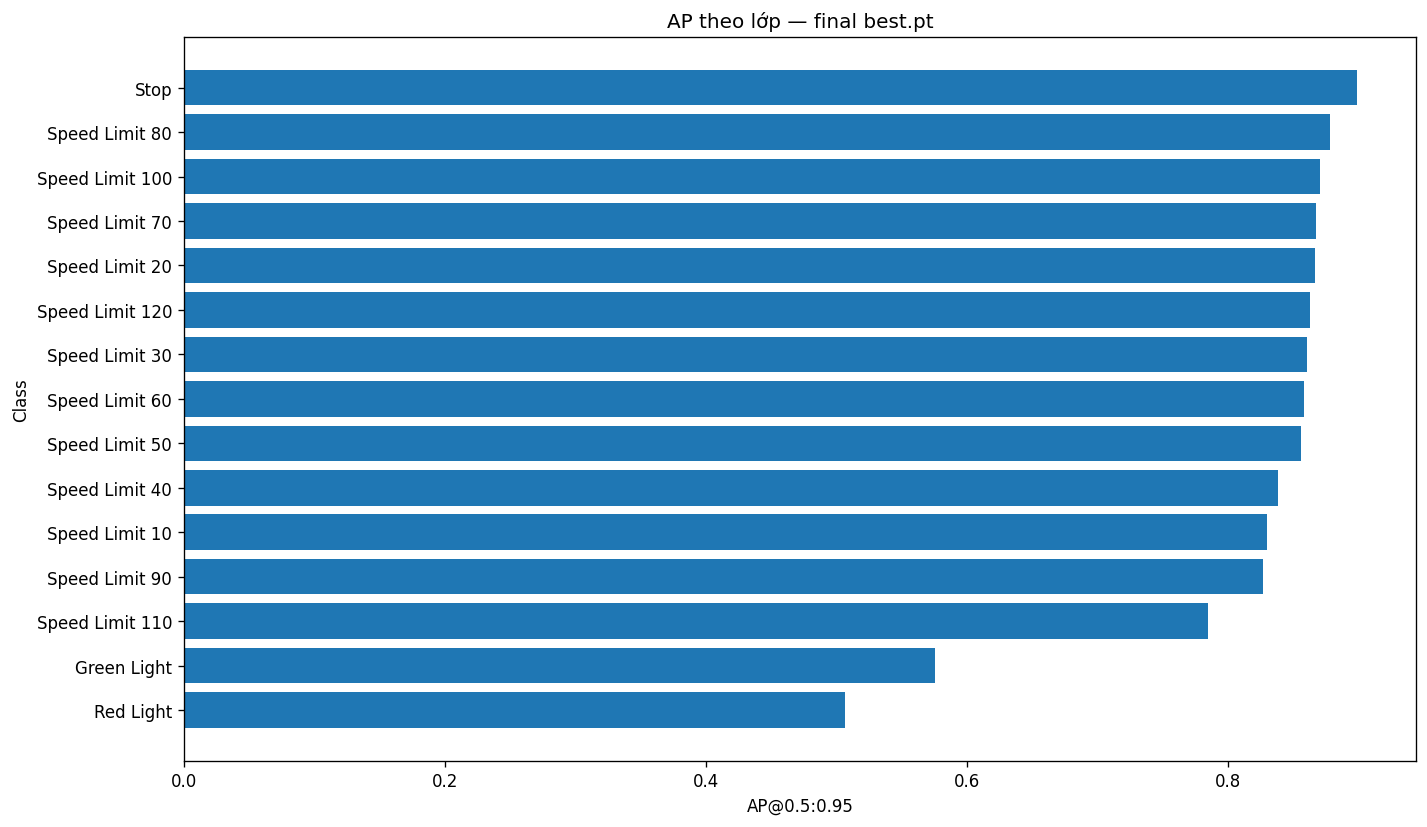

,class_id,class_name,precision,recall,ap50,ap50_95
14,14,Stop,0.998511,1.000000,0.995000,0.899068
12,12,Speed Limit 80,0.976662,1.000000,0.995000,0.877975
3,3,Speed Limit 100,0.967628,1.000000,0.994149,0.870534
11,11,Speed Limit 70,0.921754,0.943396,0.973431,0.867052
6,6,Speed Limit 20,0.971896,0.978261,0.973261,0.866319
5,5,Speed Limit 120,0.930134,1.000000,0.985494,0.863016
7,7,Speed Limit 30,0.983039,0.966005,0.983833,0.860135
10,10,Speed Limit 60,1.000000,0.932761,0.991676,0.858572
9,9,Speed Limit 50,0.927570,0.960000,0.987289,0.856111
8,8,Speed Limit 40,0.976522,0.962264,0.981858,0.838153


In [29]:
# ==========================================================
# 14.3 Per-class metrics
# ==========================================================
if final_metrics is not None:
    box_metric = final_metrics.box

    def metric_array(obj, attr, n):
        value = getattr(obj, attr, None)
        if value is None:
            return np.full(n, np.nan)
        try:
            arr = np.asarray(value, dtype=float).reshape(-1)
            if len(arr) == n:
                return arr
        except Exception:
            pass
        return np.full(n, np.nan)

    per_class_df = pd.DataFrame({
        "class_id": range(NC),
        "class_name": CLASS_NAMES,
        "precision": metric_array(box_metric, "p", NC),
        "recall": metric_array(box_metric, "r", NC),
        "ap50": metric_array(box_metric, "ap50", NC),
        "ap50_95": metric_array(box_metric, "ap", NC),
    })

    maps = getattr(box_metric, "maps", None)
    if maps is not None:
        maps = np.asarray(maps, dtype=float).reshape(-1)
        if len(maps) == NC:
            per_class_df["ap50_95"] = maps

    per_class_df.to_csv(
        TABLE_DIR / "per_class_metrics.csv",
        index=False,
    )

    plt.figure(figsize=(12, 7))
    plot_df = per_class_df.sort_values("ap50_95")
    plt.barh(plot_df["class_name"], plot_df["ap50_95"])
    plt.xlabel("AP@0.5:0.95")
    plt.ylabel("Class")
    plt.title("AP theo lớp — final best.pt")
    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "final_per_class_ap50_95.png",
        bbox_inches="tight",
        dpi=180,
    )
    plt.show()
    plt.close()

    display(
        per_class_df.sort_values(
            "ap50_95",
            ascending=False,
        )
    )
else:
    per_class_df = pd.DataFrame({
        "class_id": range(NC),
        "class_name": CLASS_NAMES,
        "precision": np.nan,
        "recall": np.nan,
        "ap50": np.nan,
        "ap50_95": np.nan,
    })
    per_class_df.to_csv(
        TABLE_DIR / "per_class_metrics.csv",
        index=False,
    )
    print(
        "Per-class metrics skipped because evaluation failed. "
        "best.pt is still preserved."
    )

In [30]:
# ==========================================================
# 14.4 Qualitative predictions
# ==========================================================
source_split = "test" if "test" in SPLIT_IMAGE_DIRS else "valid"
source_dir = SPLIT_IMAGE_DIRS[source_split]
prediction_images = sorted([
    p for p in source_dir.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

random.Random(SEED).shuffle(prediction_images)
prediction_images = prediction_images[:24]

if prediction_images:
    try:
        final_model.predict(
        source=[str(p) for p in prediction_images],
        imgsz=eval_imgsz,
        conf=0.25,
        iou=0.60,
        max_det=300,
        device=DEVICE,
        save=True,
        project=str(PRED_DIR),
        name="final_best_predictions",
        exist_ok=True,
        verbose=False,
        )
        print(
            "Saved prediction samples:",
            PRED_DIR / "final_best_predictions",
        )
    except Exception:
        prediction_error = traceback.format_exc()
        (REPORT_DIR / "prediction_error.txt").write_text(
            prediction_error,
            encoding="utf-8",
        )
        print("Prediction visualization failed; best.pt remains available.")
else:
    print("No images found for prediction visualization.")

Results saved to /kaggle/working/traffic_sign_yolo_pipeline/predictions/final_best_predictions
Saved prediction samples: /kaggle/working/traffic_sign_yolo_pipeline/predictions/final_best_predictions


## 15. Xuất COCO JSON để sẵn sàng cho DETR

Phần EDA trước đó đã chuyển nhãn YOLO sang COCO JSON. Đây là đầu vào chuẩn để huấn luyện DETR trong một notebook độc lập hoặc bật thêm thí nghiệm khi còn thời gian. Notebook hiện tại ưu tiên YOLO vì yêu cầu đầu ra bắt buộc là `best.pt` và cần an toàn trong giới hạn 12 giờ.

## 16. Báo cáo cuối, manifest và ZIP

In [31]:
# ==========================================================
# 16.1 Generate final scientific report
# ==========================================================
student_lines = "\n".join(
    f"- **{s['student_id']} – {s['student_name']}**"
    for s in STUDENT_INFO
)

final_report = f"""# Báo cáo Traffic Sign Detection — EDA-driven YOLO

## Thành viên

{student_lines}

## Dataset

- Nguồn: `pkdarabi/cardetection`
- Số lớp: **{NC}**
- Số ảnh quét: **{len(images_df):,}**
- Số bounding box hợp lệ: **{len(objects_df):,}**
- Tiny object (<0.1% diện tích ảnh): **{tiny_ratio:.2%}**
- Small object (<1% diện tích ảnh): **{small_ratio:.2%}**
- Imbalance ratio: **{imbalance_ratio:.2f}**
- Median cạnh ngắn bbox tại input 640: **{median_min_side_640:.2f}px**
- P10 cạnh ngắn bbox tại input 640: **{p10_min_side_640:.2f}px**

## Cấu hình được suy ra từ EDA

- Base model: **{TRAIN_PLAN['base_model']}**
- Stage 1: **imgsz={TRAIN_PLAN['stage1']['imgsz']}**, batch={TRAIN_PLAN['stage1']['batch']}, epochs tối đa={TRAIN_PLAN['stage1']['epochs']}
- Stage 2: **imgsz={TRAIN_PLAN['stage2']['imgsz']}**, batch={TRAIN_PLAN['stage2']['batch']}, epochs tối đa={TRAIN_PLAN['stage2']['epochs']}
- Không dùng horizontal/vertical flip vì có thể thay đổi ngữ nghĩa biển báo.
- AdamW + cosine learning rate + AMP.
- Checkpoint được đồng bộ sau mỗi lần model save.
- OOM fallback: giảm batch/độ phân giải, sau đó chuyển sang YOLOv8n.

## Kết quả cuối

- Evaluation split: **{FINAL_METRICS['split']}**
- Precision: **{FINAL_METRICS['precision']:.6f}**
- Recall: **{FINAL_METRICS['recall']:.6f}**
- mAP@0.5: **{FINAL_METRICS['map50']:.6f}**
- mAP@0.5:0.95: **{FINAL_METRICS['map50_95']:.6f}**
- Inference latency: **{FINAL_METRICS['inference_ms_per_image']:.3f} ms/ảnh**
- FPS ước lượng từ inference: **{FINAL_METRICS['fps_from_inference_only']:.2f}**
- Model size: **{FINAL_METRICS['model_size_mb']:.2f} MB**
- Tổng thời gian notebook đến thời điểm báo cáo: **{elapsed_hours():.2f} giờ**

## Checkpoint cuối

- `{FINAL_BEST}`
- `{KAGGLE_BEST}`

Thông tin provenance nằm trong `checkpoint_state.json`.
"""

(REPORT_DIR / "FINAL_REPORT.md").write_text(
    final_report, encoding="utf-8"
)
print(final_report)

# Báo cáo Traffic Sign Detection — EDA-driven YOLO

## Thành viên

- **KHMT836016 – Huỳnh Phát Lợi**
- **KHMT836034 – Đoàn Huỳnh Thanh Tú**
- **KHMT836036 – Võ Phú Vinh**

## Dataset

- Nguồn: `pkdarabi/cardetection`
- Số lớp: **15**
- Số ảnh quét: **4,969**
- Số bounding box hợp lệ: **6,012**
- Tiny object (<0.1% diện tích ảnh): **18.68%**
- Small object (<1% diện tích ảnh): **36.58%**
- Imbalance ratio: **35.77**
- Median cạnh ngắn bbox tại input 640: **118.08px**
- P10 cạnh ngắn bbox tại input 640: **7.69px**

## Cấu hình được suy ra từ EDA

- Base model: **yolov8s.pt**
- Stage 1: **imgsz=640**, batch=16, epochs tối đa=60
- Stage 2: **imgsz=768**, batch=10, epochs tối đa=35
- Không dùng horizontal/vertical flip vì có thể thay đổi ngữ nghĩa biển báo.
- AdamW + cosine learning rate + AMP.
- Checkpoint được đồng bộ sau mỗi lần model save.
- OOM fallback: giảm batch/độ phân giải, sau đó chuyển sang YOLOv8n.

## Kết quả cuối

- Evaluation split: **test**
- Precision: **0.960291**
- Recal

In [32]:
# ==========================================================
# 16.2 Finalize outputs, hashes, manifest and ZIP
# ==========================================================
import hashlib

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

assert FINAL_BEST.exists()
atomic_copy(FINAL_BEST, KAGGLE_BEST)
atomic_copy(FINAL_BEST, FINAL_DIR / "best.pt")
atomic_copy(STATE_PATH, FINAL_DIR / "checkpoint_state.json")
atomic_copy(
    REPORT_DIR / "final_metrics.json",
    FINAL_DIR / "final_metrics.json",
)
atomic_copy(
    REPORT_DIR / "FINAL_REPORT.md",
    FINAL_DIR / "FINAL_REPORT.md",
)

artifact_summary = {
    "best_pt": str(KAGGLE_BEST),
    "best_pt_size_mb": KAGGLE_BEST.stat().st_size / 1024**2,
    "best_pt_sha256": sha256_file(KAGGLE_BEST),
    "checkpoint_state": json.loads(
        STATE_PATH.read_text(encoding="utf-8")
    ),
    "final_metrics": FINAL_METRICS,
    "students": STUDENT_INFO,
}
(OUT_DIR / "artifact_summary.json").write_text(
    json.dumps(artifact_summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

manifest_rows = []
for path in sorted(OUT_DIR.rglob("*")):
    if path.is_file():
        manifest_rows.append({
            "relative_path": str(path.relative_to(OUT_DIR)),
            "size_bytes": path.stat().st_size,
            "size_mb": path.stat().st_size / 1024**2,
        })

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(
    OUT_DIR / "output_manifest.csv",
    index=False,
)

zip_base = (
    Path("/kaggle/working/traffic_sign_yolo_pipeline_outputs")
    if IS_KAGGLE
    else Path("./traffic_sign_yolo_pipeline_outputs")
)
zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=OUT_DIR,
)

print("=" * 80)
print("PIPELINE COMPLETED")
print("Mandatory checkpoint:", KAGGLE_BEST)
print(
    "Size:",
    round(KAGGLE_BEST.stat().st_size / 1024**2, 2),
    "MB",
)
print("SHA256:", artifact_summary["best_pt_sha256"])
print("Full output directory:", OUT_DIR)
print("ZIP:", zip_path)
print("Saved files:", len(manifest_df))
print("Elapsed hours:", round(elapsed_hours(), 3))
display(manifest_df.tail(30))

PIPELINE COMPLETED
Mandatory checkpoint: /kaggle/working/best.pt
Size: 21.51 MB
SHA256: d91c3554a4ebd6b5bc1ce9b5f8c710bdbc58ed1baea34ce9ca2afc496f200a2f
Full output directory: /kaggle/working/traffic_sign_yolo_pipeline
ZIP: /kaggle/working/traffic_sign_yolo_pipeline_outputs.zip
Saved files: 187
Elapsed hours: 2.028


,relative_path,size_bytes,size_mb
157,training_runs/stage1_eda_plan/val_batch1_label...,512581,0.488835
158,training_runs/stage1_eda_plan/val_batch1_pred.jpg,520639,0.496520
159,training_runs/stage1_eda_plan/val_batch2_label...,528959,0.504455
160,training_runs/stage1_eda_plan/val_batch2_pred.jpg,530965,0.506368
161,training_runs/stage1_eda_plan/weights/best.pt,22530922,21.487162
162,training_runs/stage1_eda_plan/weights/last.pt,22530922,21.487162
163,training_runs/stage2_eda_plan/BoxF1_curve.png,355680,0.339203
164,training_runs/stage2_eda_plan/BoxPR_curve.png,227339,0.216807
165,training_runs/stage2_eda_plan/BoxP_curve.png,252252,0.240566
166,training_runs/stage2_eda_plan/BoxR_curve.png,324567,0.309531


## 17. Cấu trúc output dự kiến

```text
/kaggle/working/
├── best.pt
├── traffic_sign_yolo_pipeline_outputs.zip
└── traffic_sign_yolo_pipeline/
    ├── best.pt
    ├── artifact_summary.json
    ├── checkpoint_state.json
    ├── tables/
    ├── figures/
    ├── samples/
    ├── coco_annotations/
    ├── model_ready/
    ├── training_runs/
    ├── evaluation/
    ├── predictions/
    ├── checkpoints/
    ├── reports/
    └── final_output/
        ├── best.pt
        ├── checkpoint_state.json
        ├── final_metrics.json
        └── FINAL_REPORT.md
```

### Ý nghĩa trạng thái checkpoint

- `pretrained_fallback`: session dừng trước khi có checkpoint fine-tuned.
- `trained_checkpoint`: `best.pt` đã được thay bằng checkpoint huấn luyện.
- `selected_by_validation`: đã so sánh các stage và chọn model có mAP@0.5:0.95 validation tốt nhất.